In [101]:
import numpy as np
from tabulate import tabulate

Conversión de unidades

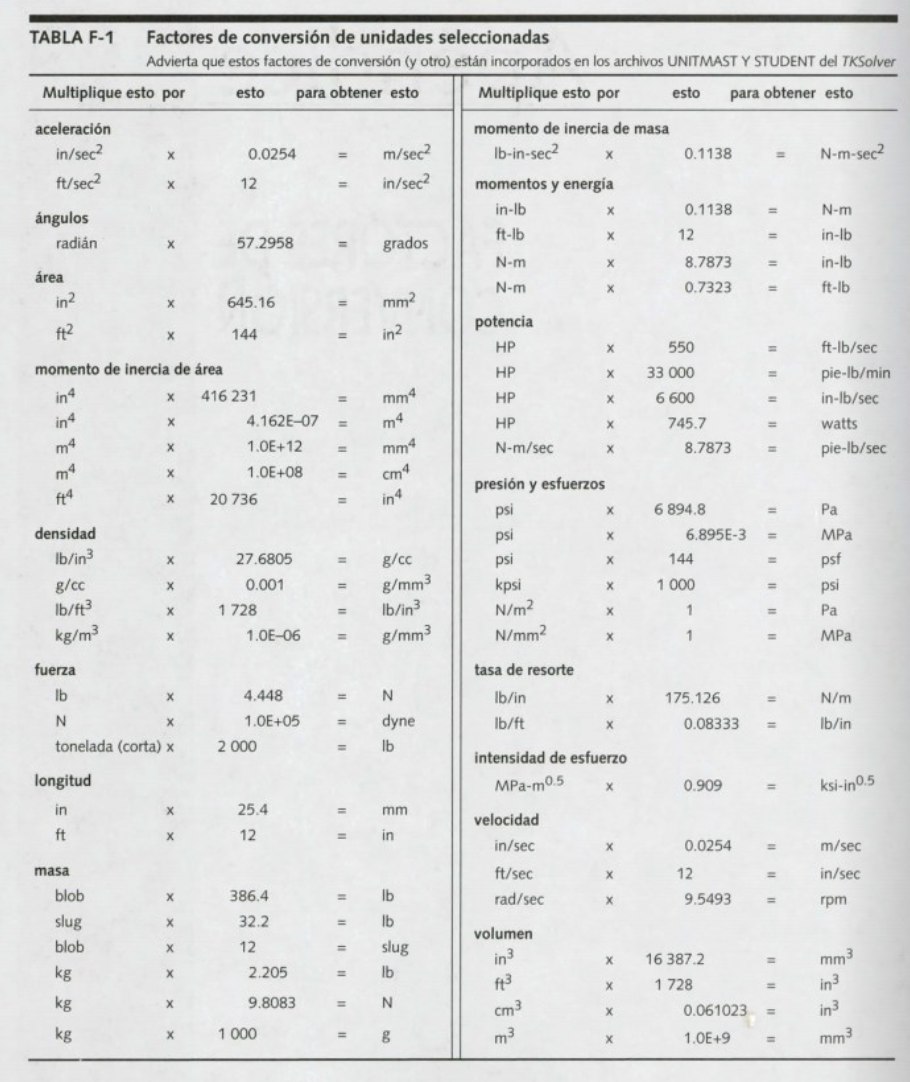
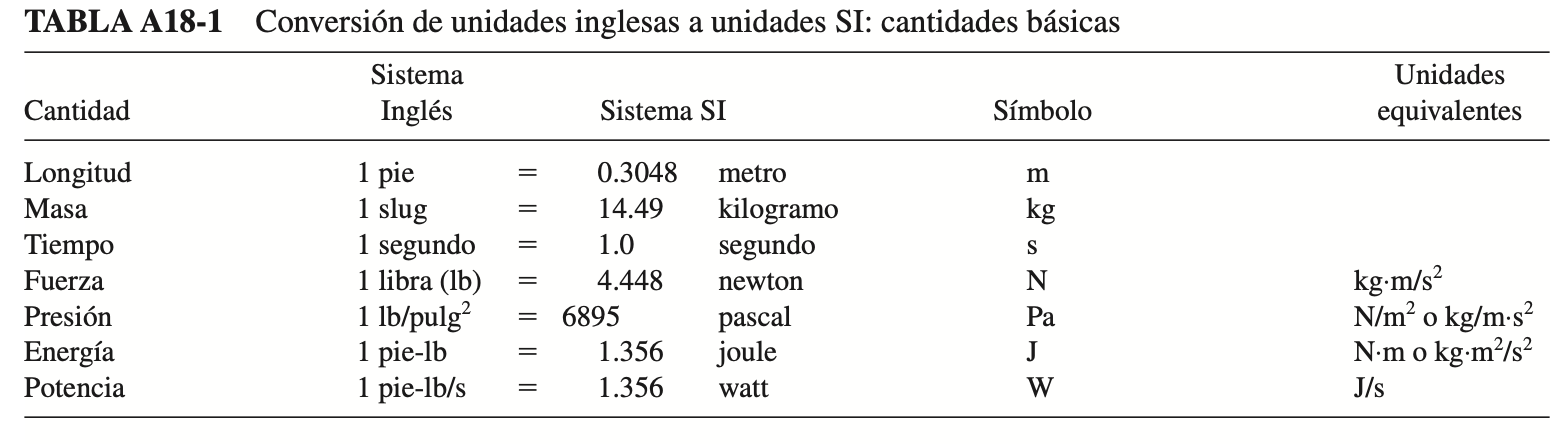
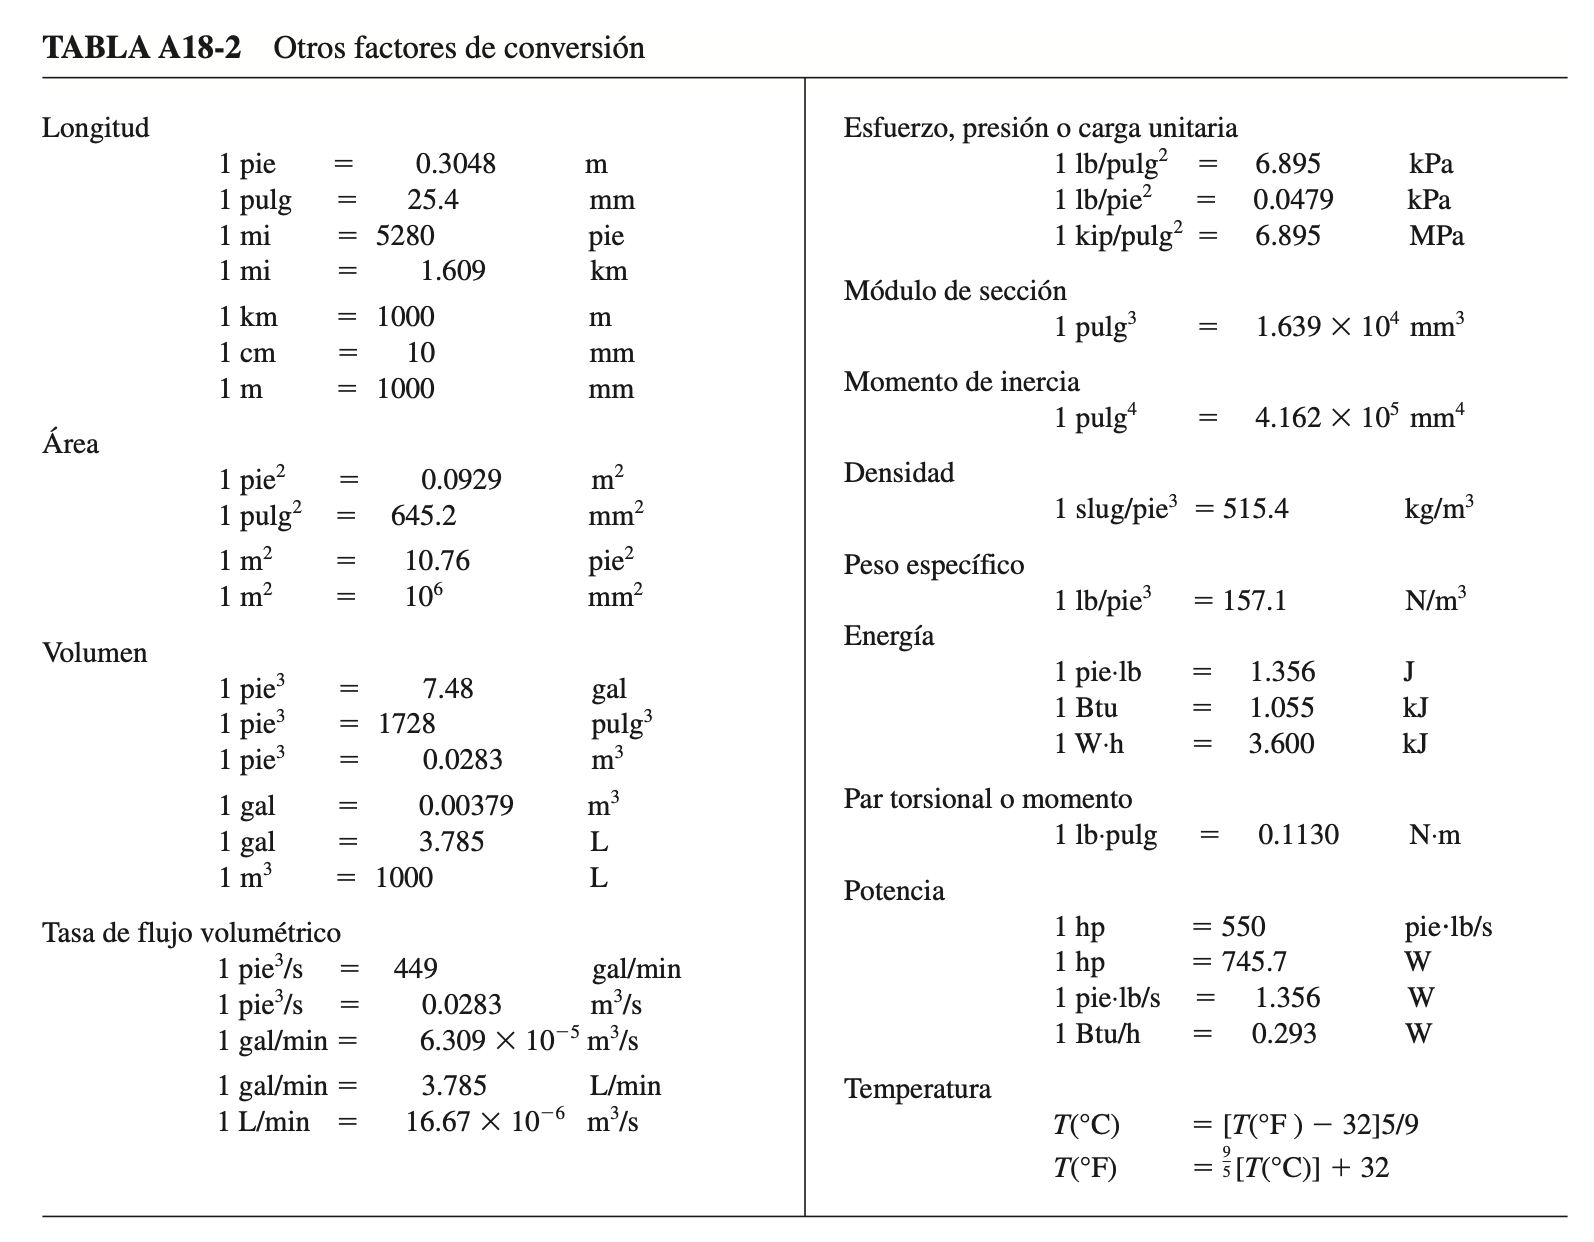

In [102]:
def inch_to_mm(value):
    return value * 25.4

def mm_to_inch(value):
    return value / 25.4

def rad_to_deg(value):
    return value * (180 / np.pi)

def deg_to_rad(value):
    return value * (np.pi / 180)

def rpm_to_radps(value):
    return value * (2 * np.pi / 60)

def radps_to_rpm(value):
    return value * (60 / (2 * np.pi))

def celsius_to_fahrenheit(celsius):
    return (celsius * 9/5) + 32

def fahrenheit_to_celsius(fahrenheit):
    return (fahrenheit - 32) * 5/9

def hp_to_watt(hp):
    return hp * 745.7

def psi_a_mpa(psi):
    return psi * 0.00689476

def Nm_to_lbin(Nm):
    return Nm * 0.1138

def lbin_to_Nm(lbft):
    return lbft / 0.1138

def Nm_to_lbft(Nm):
    return Nm * 0.7323

def lbft_to_Nm(lbft):
    return lbft / 0.7323

# Correas

## Bandas Planas

### Geometría de bandas planas

**Banda abierta no inversora**

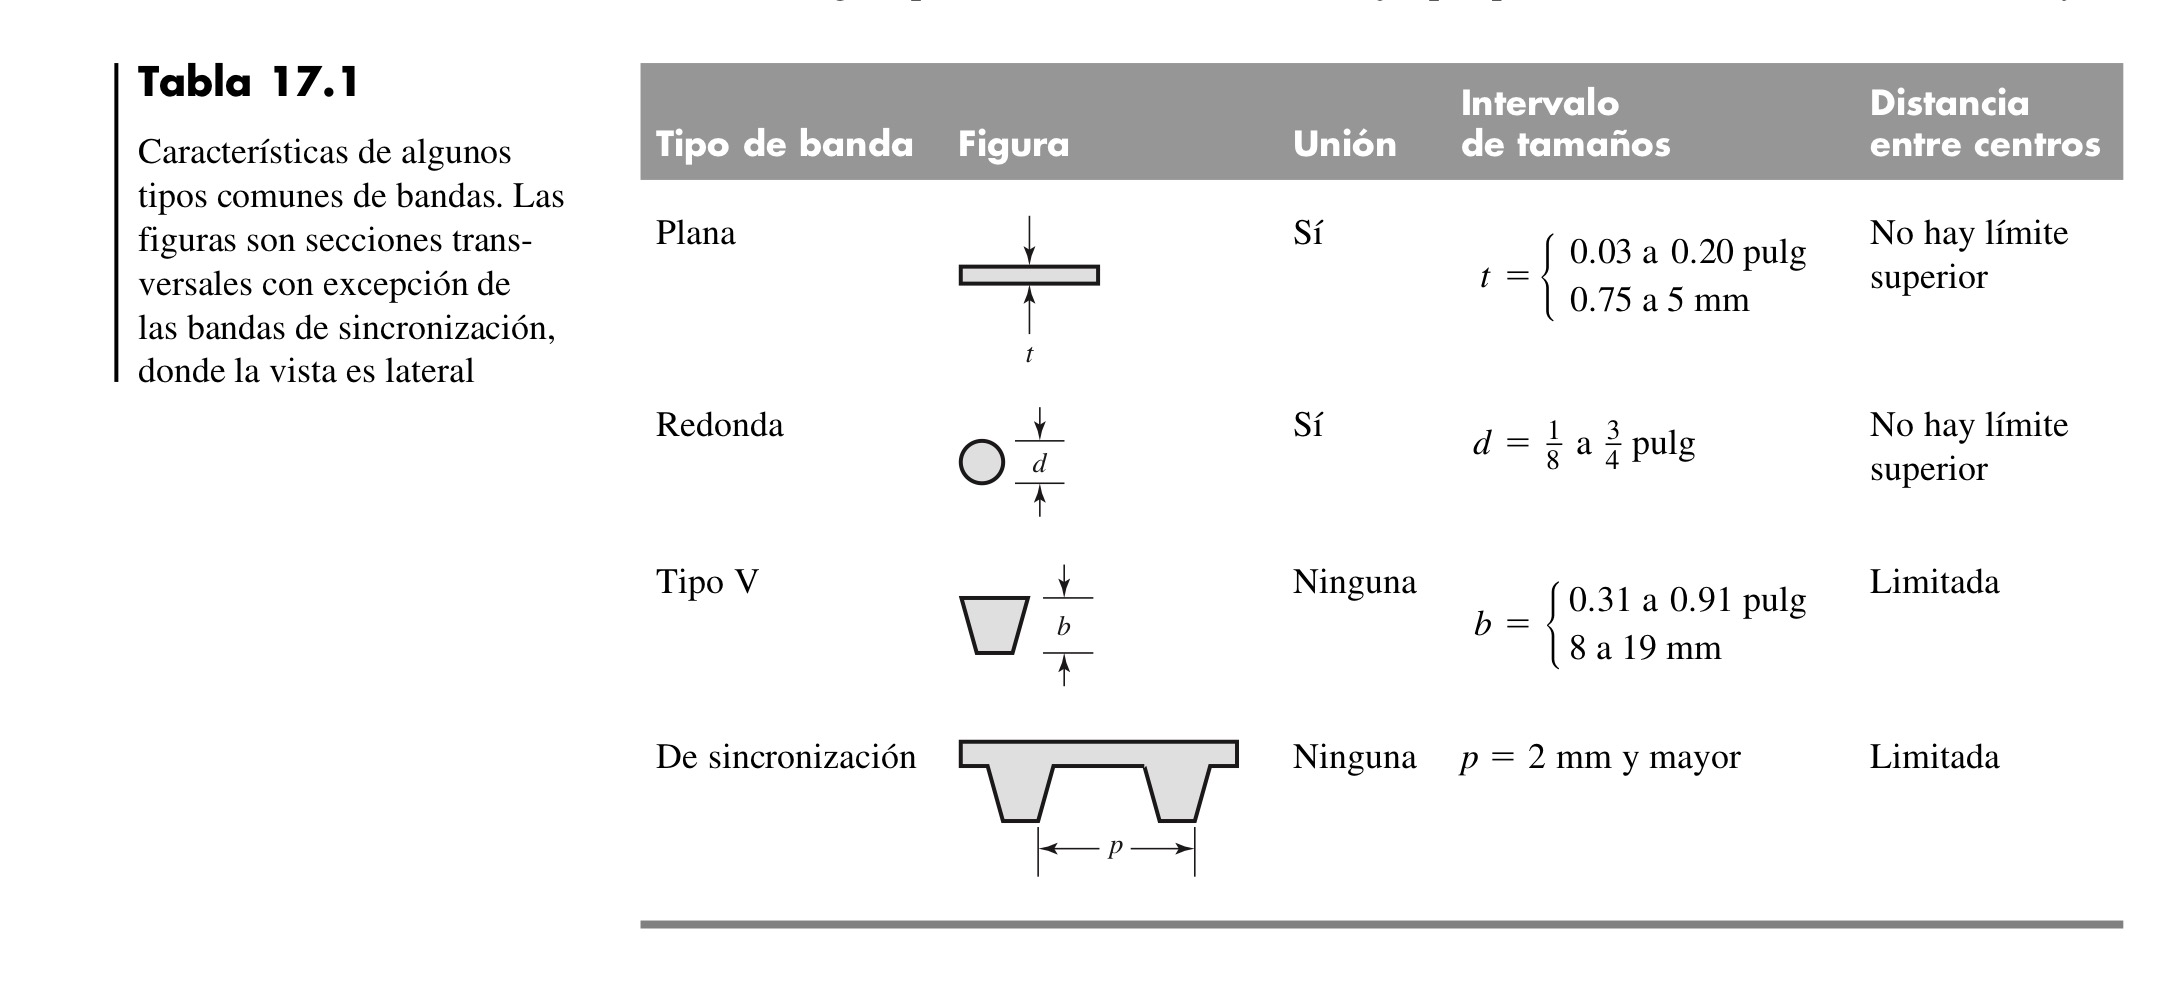

El ángulo de contacto de la polea impulsora (la más chica) está dado por:

$$
\alpha_1 = \pi - 2\sin^{-1} \frac{D_2 - D_1}{2C}
$$

De forma similar, el ángulo de contacto de la polea impulsada (la más grande) con la banda está dado por:

$$
\alpha_2 = \pi + 2\sin^{-1} \frac{D_2 - D_1}{2C}
$$

Donde $C$ es la distancia entre centros de las poleas. 

La longitud de paso de esta banda es:

$$
L_p = \pi \frac{D_1 + D_2}{2} + \frac{(D_2 - D_1)^2}{4C} + 2C
$$

In [103]:
def alpha_1_function(C, D, d):
    '''Recibe:
    C: Distancia entre centros [m]
    D: Diámetro de la polea mayor [m]
    d: Diámetro de la polea menor [m]
    
    Retorna:
    alpha_1: Ángulo de contacto en la polea menor [rad]'''

    return np.pi - (2 * np.arcsin((D - d) / (2 * C)))

def alpha_2_function(C, D, d):
    '''Recibe:
    C: Distancia entre centros [m]
    D: Diámetro de la polea mayor [m]
    d: Diámetro de la polea menor [m]
    
    Retorna:
    alpha_2: Ángulo de contacto en la polea mayor [rad]'''

    return np.pi + (2 * np.arcsin((D - d) / (2 * C)))

def largo_paso_banda_plana(C, D, d):
    '''Recibe:
    C: Distancia entre centros [m]
    D: Diámetro de la polea mayor [m]
    d: Diámetro de la polea menor [m]
    
    Retorna:
    L: Largo del paso de la banda plana [m]'''


    L = (np.pi * (D + d) / 2) + (2 * C) + ((D - d)**2 / (4 * C))

    return L

### Ecuación de bandas planas

La ecuación de las bandas planas está dada por:

$$
\frac{T_1 - T_c}{T_2 - T_c} = e^{f\cdot \phi_D}
$$

- $T_1$: Tensión del ramal tenso de la correa
- $T_2$ Tensión del ramal flojo de la correa
- $T_c = mr^2 \omega^2$: Fuerza centrífuga por unidad de ángulo. $m$ es la masa por unidad de longitud ($m = \frac{\gamma}{g}bt$ con $b$ el ancho de la banda y $t$ el espesor de la banda), $r$ es el radio de la polea y $\omega$ es la velocidad angular de la polea
- $f$: Factor de fricción de la correa
- $\phi_D$: Ángulo de contacto entre la banda y la polea

Por definición, se debe cumplir también que:

$$
T_1 - T_2 = \frac{2M}{D}
$$

Donde $M$ es el momento transmitido por la polea y $D$ el diámetro de la polea. Por lo tanto, la ecuación de las bandas planas podría ser reescrita y, gracias a unos arreglos matemáticos, obtener la tensión inicial requerida para la transmisión de torque.

$$
T_{inicial} = \frac{M}{D} \frac{e^{f\cdot \phi_D} + 1}{e^{f\cdot \phi_D} - 1}
$$

In [104]:
def T_c_function(gamma, b, t, V):
    '''Recibe:
    gamma: Peso específico de la banda [lbf/in³]
    b: Ancho de la banda [in]
    t: Espesor de la banda [in]
    omega: Velocidad angular de la polea [rpm]
    r: Radio de la polea [in]
    
    Retorna:
    T_c: Tensión centrífuga en la banda [N]'''

    # Se trabaja con los factores de conversión dentro de esta fórmula

    T_c = (gamma / 32.17) * b * t * ((V / 60)**2)

    return T_c

def velocity_function(omega, d):
    '''Recibe:
    omega: Velocidad angular de la polea [rpm]
    d: Diámetro de la polea [in]
    
    Retorna:
    V: Velocidad lineal de la banda [ft/min]'''

    V = (omega * np.pi * d) / 12

    return V

### Seguridad en bandas planas

El factor de seguridad en bandas planas se calcula con la siguiente fórmula:

$$
n_d = \frac{H_{adm}}{H_d}
$$

Donde $H_{adm}$ es la potencia admisible por la banda y $H_d = H_{nom} \cdot K_s$ es la potencia transmitida con el factor de aplicación $K_s$. La potencia nominal está dada por:

$$
H_{nom} = (T_1 - T_2) \cdot V
$$
Donde $V$ es la velocidad lineal de la banda. $V = \frac{\omega D}{2}$.

Los fabricantes especifican la tensión máxima admisible $T_{adm}$. La tensión 1 admisible en función de esta tensión tabulada es:

$$
(T_1)_{adm} = bT_{adm} C_p C_v
$$

Donde:
- $b$: Ancho de la banda
- $C_p$: Factor de corrección por tamaño
- $C_v$: Factor de corrección por velocidad

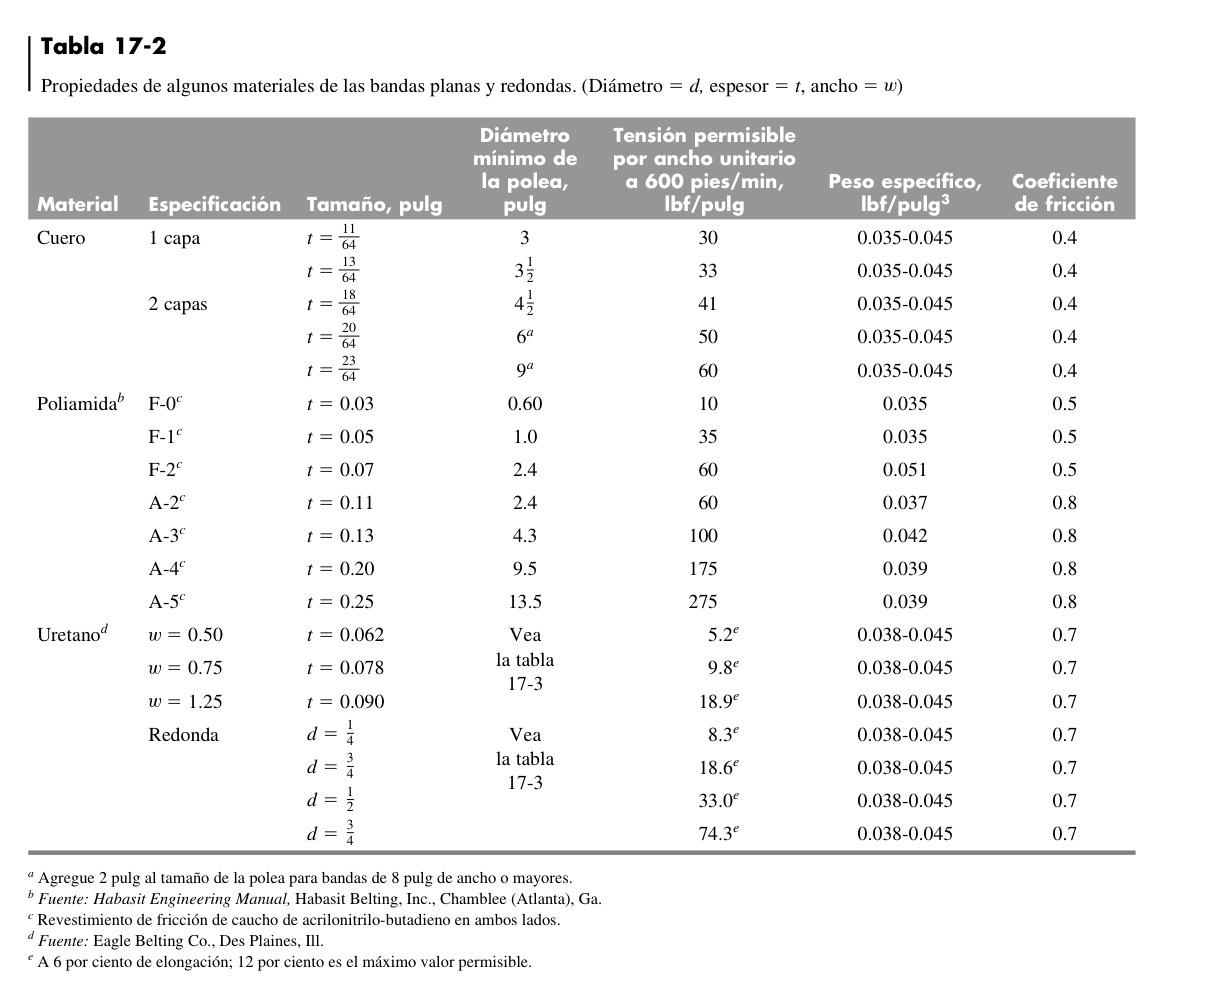
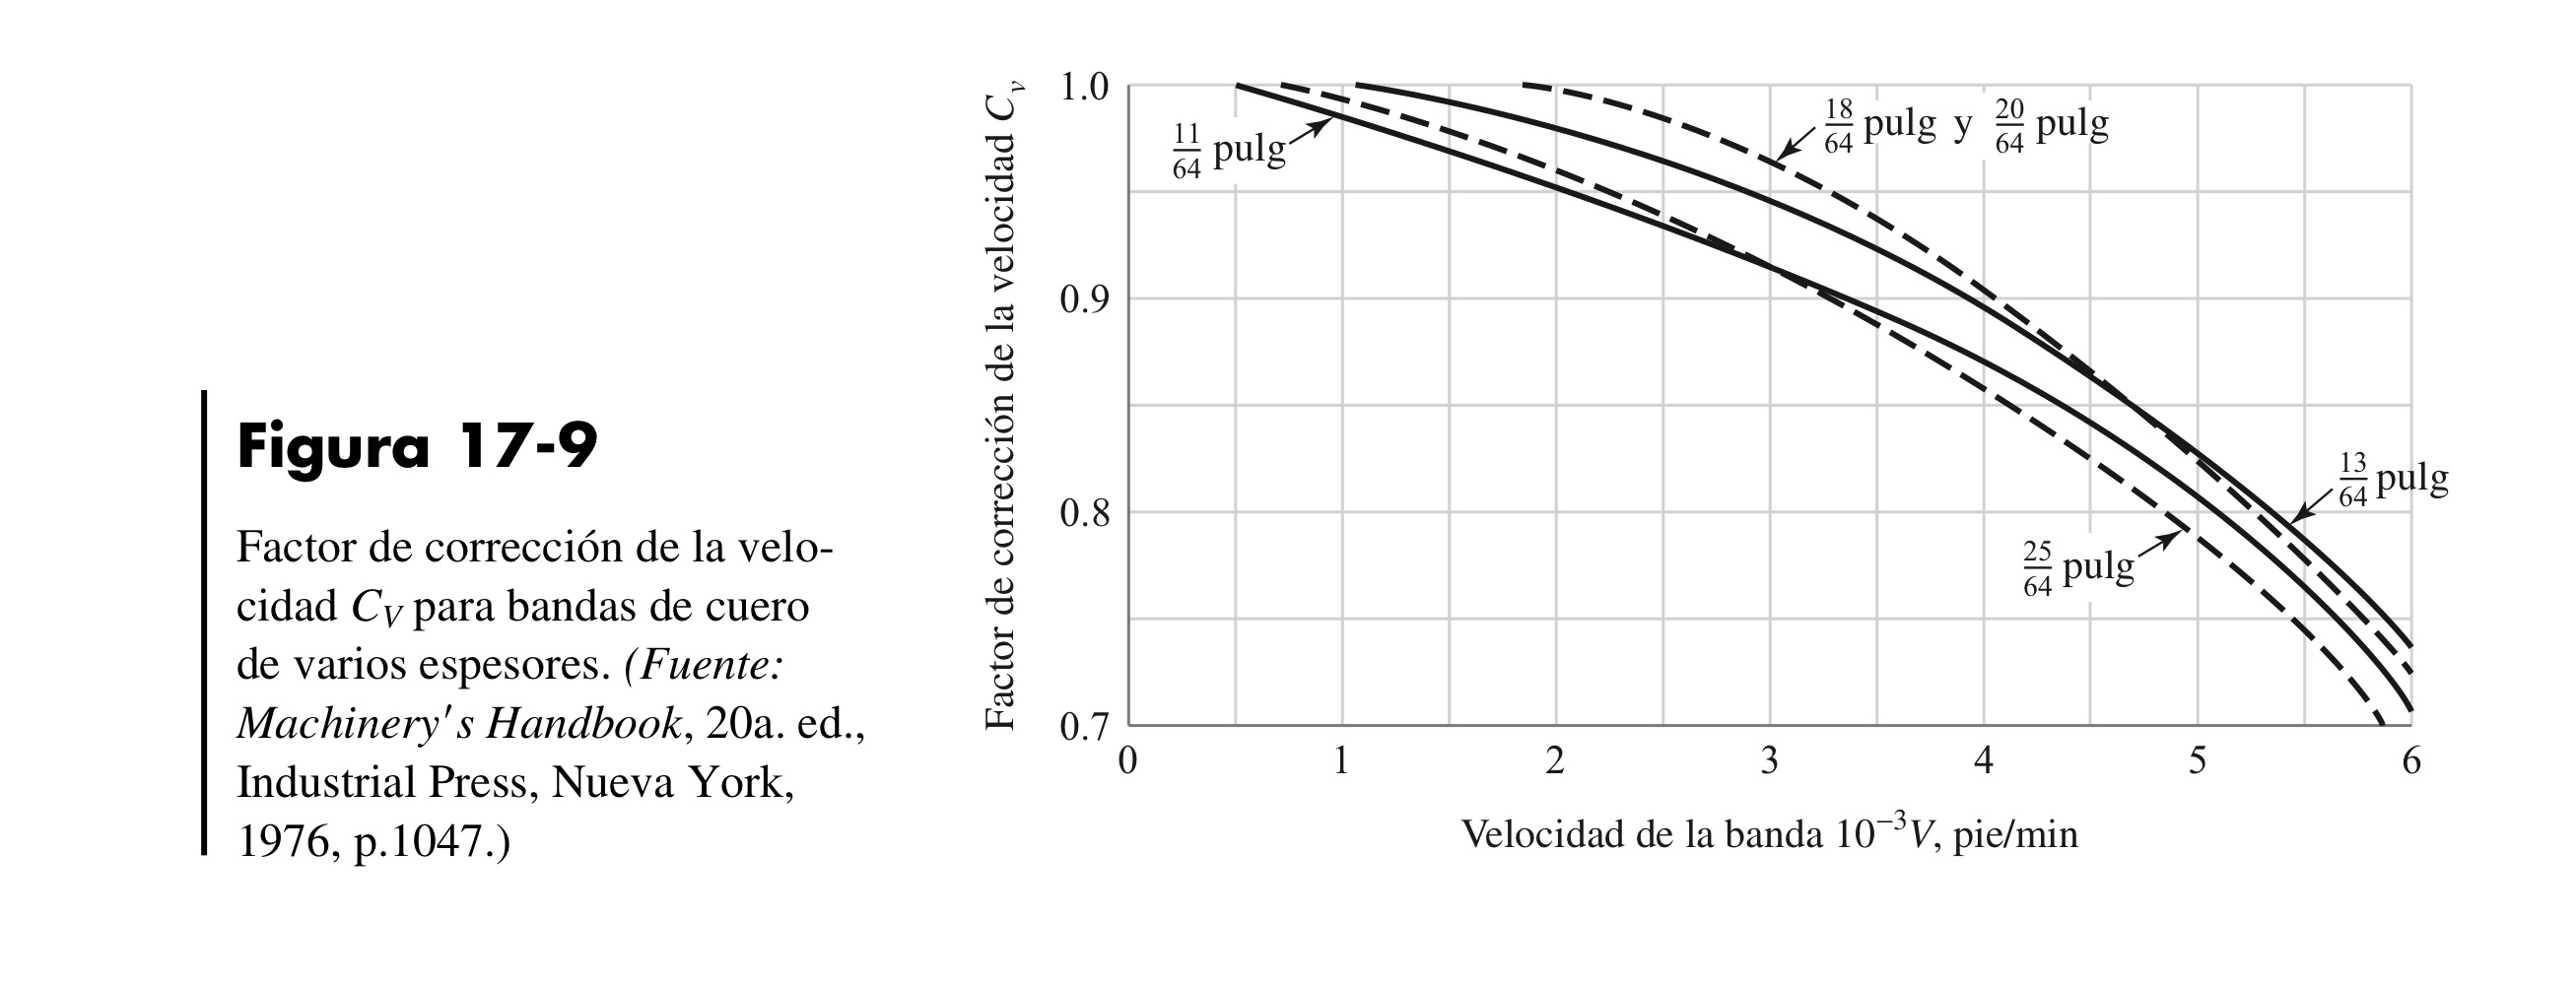
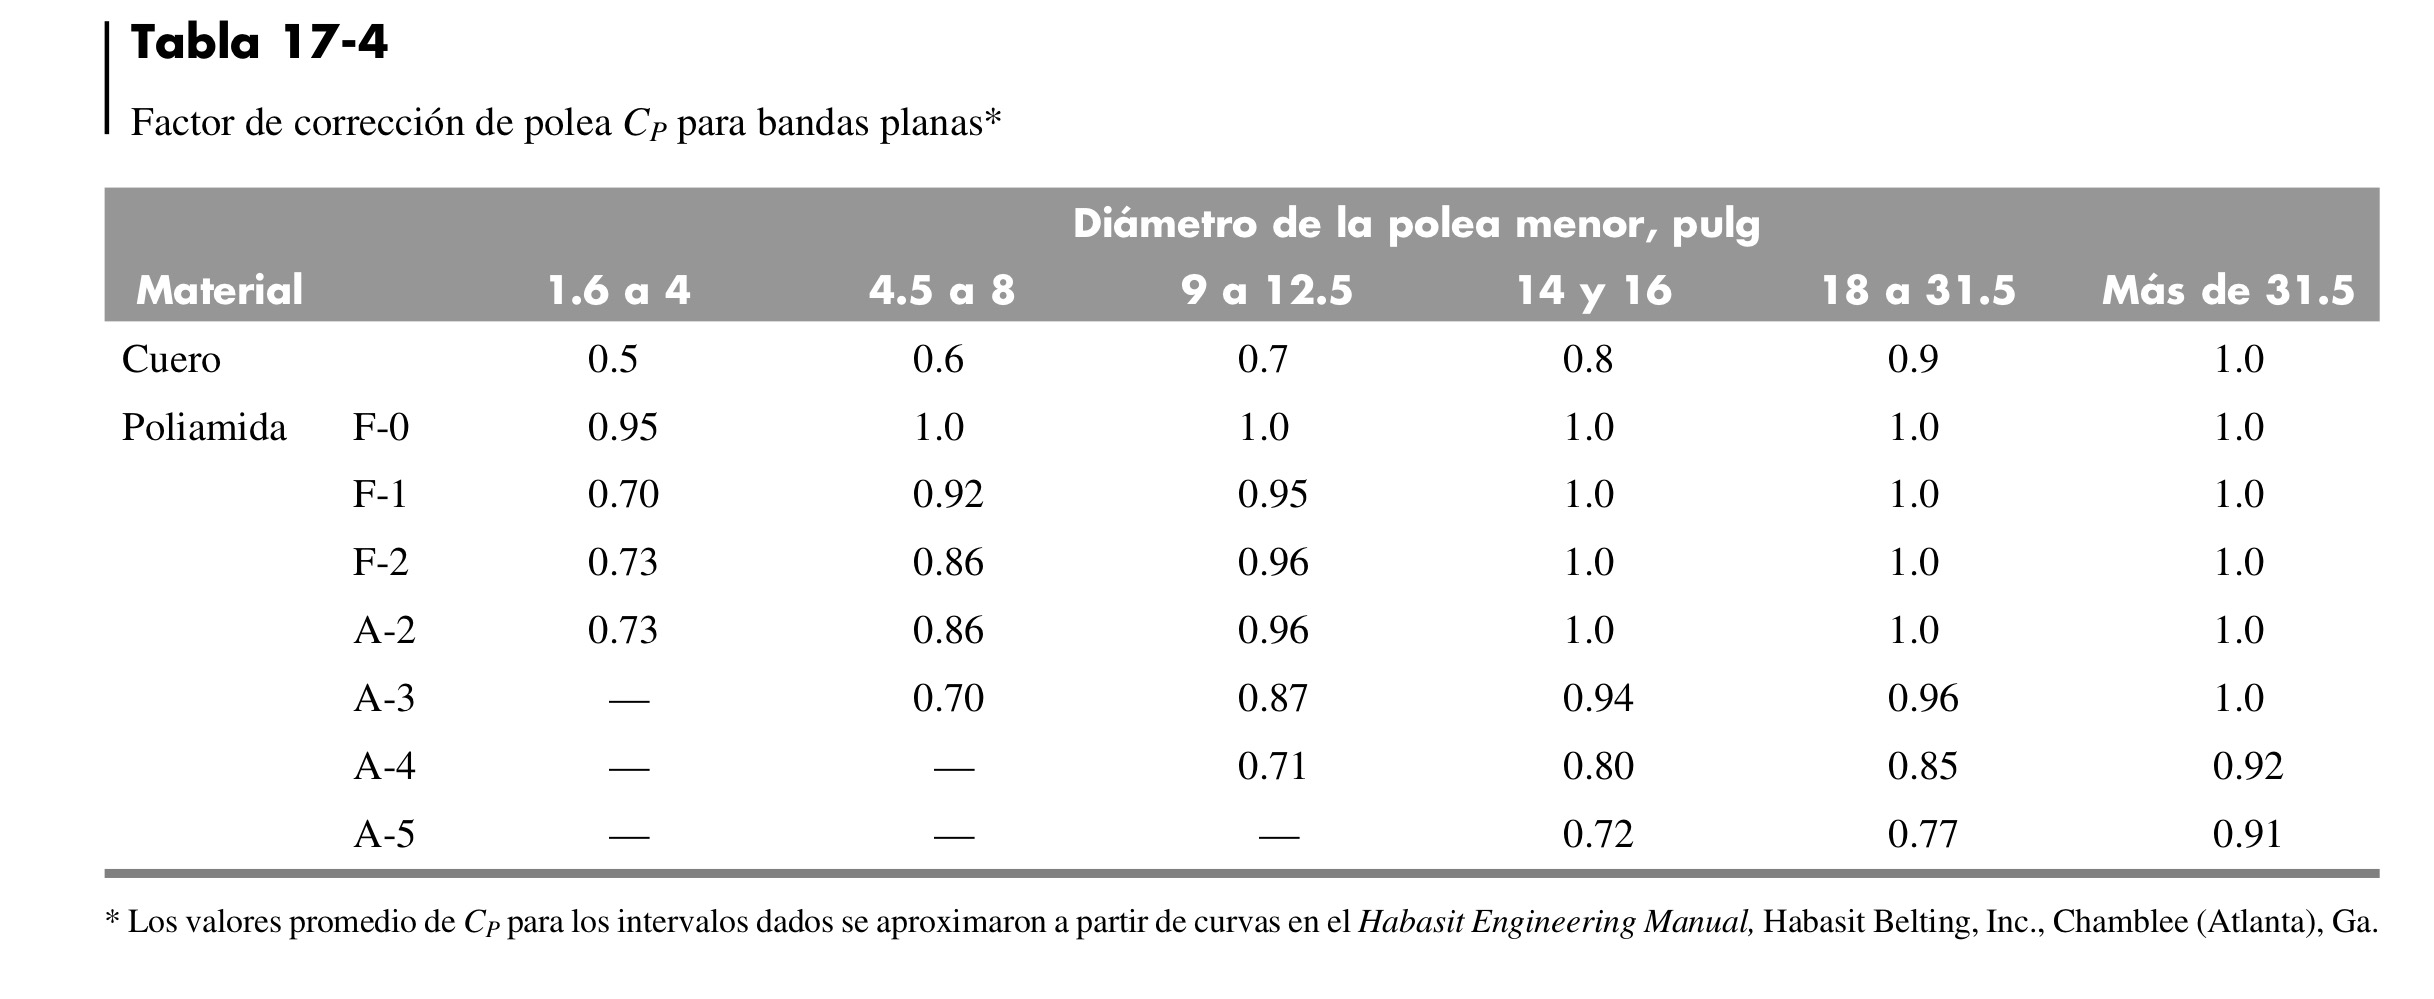


El paso a paso para obtener el factor de seguridad de una banda plana es:

1. Calcular $\phi_D$ y $L_p$
2. Calcular $T_c$
3. Calcular $M_{adm} = 63025 \frac{H_{nom} K_s n_d}{n}$, con $n$ la velocidad de la banda
4. Calcular $T_1$ usando $T_{1_{adm}} = b T_{1_{tab}} C_p C_v$
5. Calcular $T_2$ usando $T_1 - T_2 = 2\frac{M_{adm}}{D}$
6. Calcular $f' = \frac{1}{\phi_D} \ln \frac{T_{1_{adm}} - Tc}{T_2 - T_c}$ y verificar que se cumpla que $f' < f$
7. Calcular el factor de seguridad real $n_{d,real} = \frac{H_{adm}}{H_{nom} K_s}$


In [105]:
def chequear_seguridad_banda(D, d, C, H_nom, omega, n_d, f, T_tabulada, Ks, Cp, Cv, gamma, b, t):
    '''En base a los parámetros geométricos y a las propiedades de la banda,
    se determina si satisface el factor de seguridad requerido.
    
    Recibe:
    D: Diámetro de la polea mayor [m]
    d: Diámetro de la polea menor [m]
    C: Distancia entre centros [m]
    H_nom: Potencia nominal [W]
    omega: Velocidad angular de la polea menor [rpm]'''

    # 1) Calcular phi_d y L_p
    alpha_1 = alpha_1_function(C, D, d)
    largo_paso = largo_paso_banda_plana(C, D, d)

    # 2) Calcular T_c
    velocidad_banda = velocity_function(omega, d)
    T_c = T_c_function(gamma, b, t, velocidad_banda)

    # 3) Calcular (T_1)_adm
    T1_adm = T_tabulada * b * Cp * Cv

    # 4) Calcular T2
    T2 = (T1_adm + (T_c * (np.exp(f * alpha_1) - 1))) / np.exp(f * alpha_1)

    # 5) Calcular H_adm
    H_adm = (T1_adm - T2) * (velocidad_banda) / 33000 # hp

    # 6) Calcular H_d
    H_d = H_nom * Ks    

    # 7) Calcular n_d
    n_d_calculado = H_adm / H_d
    
    if n_d_calculado >= n_d:
        print(f"La banda cumple con el factor de seguridad requerido. n_d_calculado = {n_d_calculado:.2f} >= n_d {n_d}")
    else:
        print(f"La banda NO cumple con el factor de seguridad requerido ❌❌❌ . n_d_calculado = {n_d_calculado:.2f} < n_d {n_d} ")


    # Print a table with the results
    table = [
        ["Ángulo de contacto en la polea menor (rad)", f"{alpha_1:.4f}"],
        ["Largo del paso de la banda (m)", f"{largo_paso:.4f}"],
        ["Tensión centrífuga en la banda (N)", f"{T_c:.2f}"],
        ["Tensión admisible en el lado de mayor tensión (N)", f"{T1_adm:.2f}"],
        ["Tensión en el lado de menor tensión (N)", f"{T2:.2f}"],
        ["Potencia admisible (W)", f"{H_adm:.2f}"],
        ["Factor de seguridad calculado", f"{n_d_calculado:.2f}"]
    ]

    print(tabulate(table, headers=["Descripción", "Valor"], tablefmt="grid"))

## Bandas en V

### Geometría de las bandas en V

Tanto las secciones trasnversales como las longitudes de acción se encuentran tabuladas.

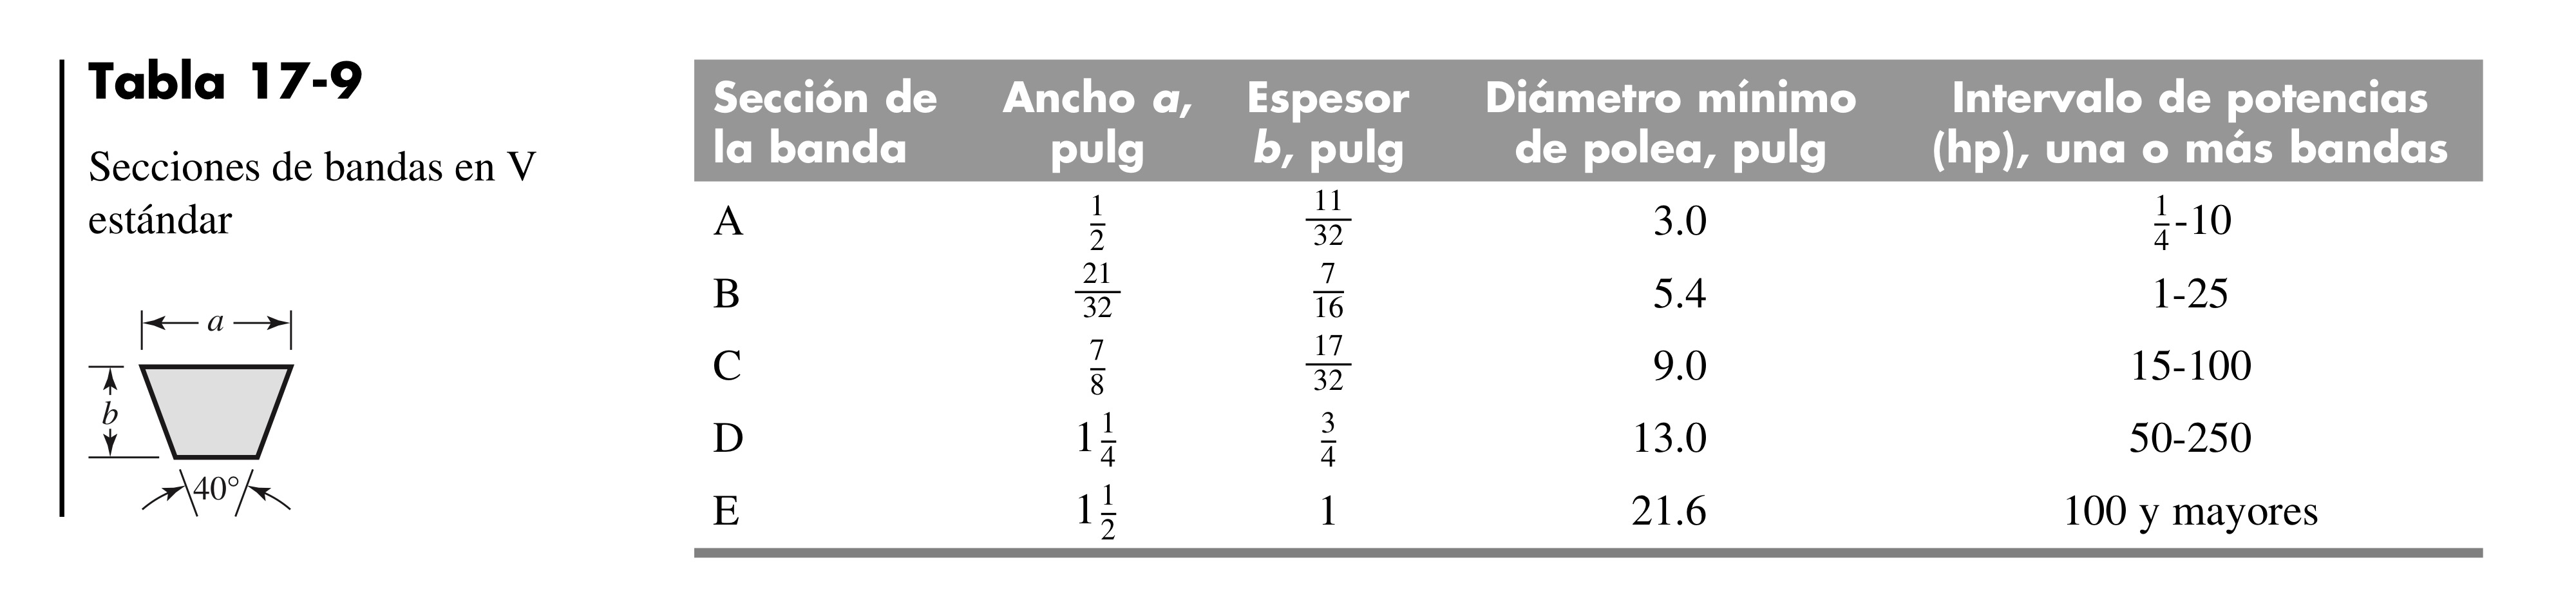 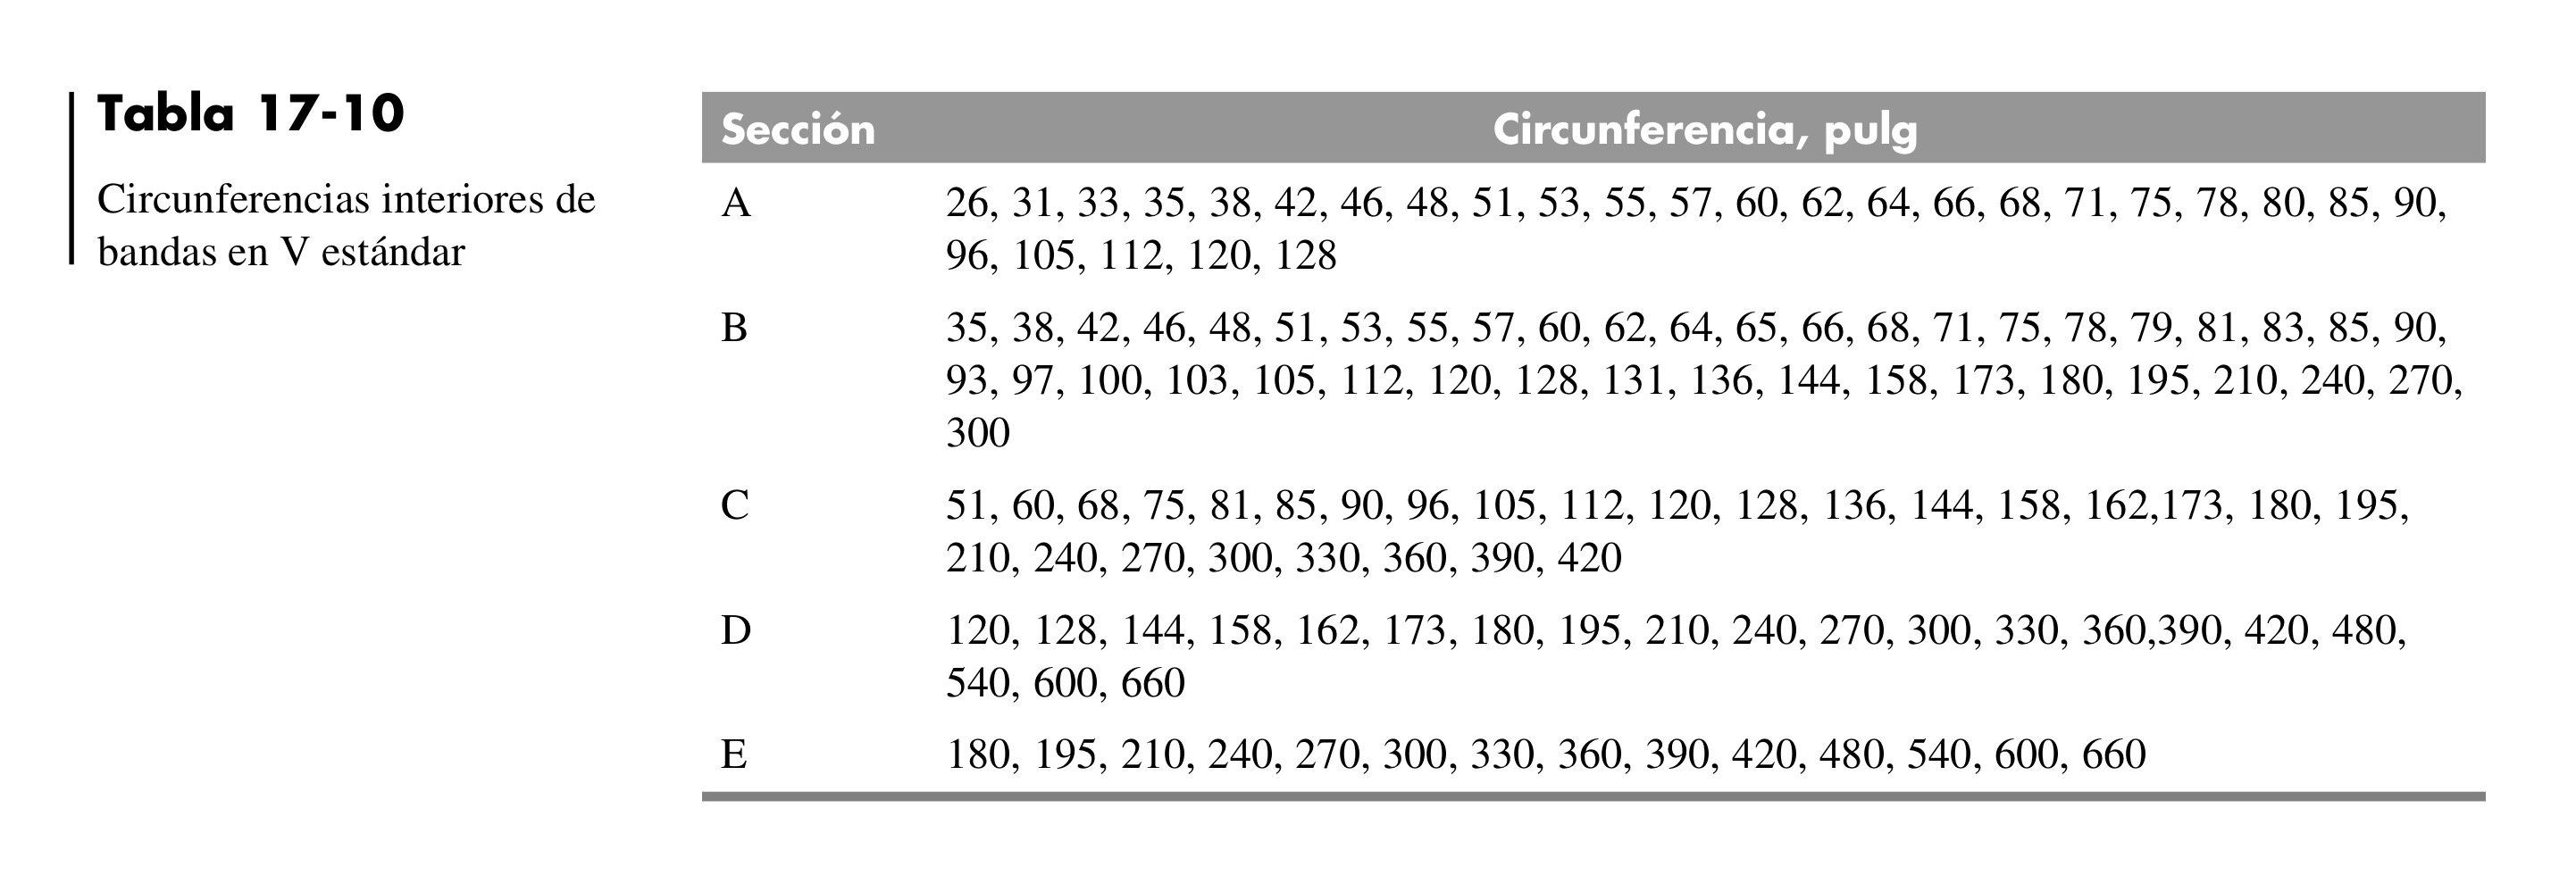 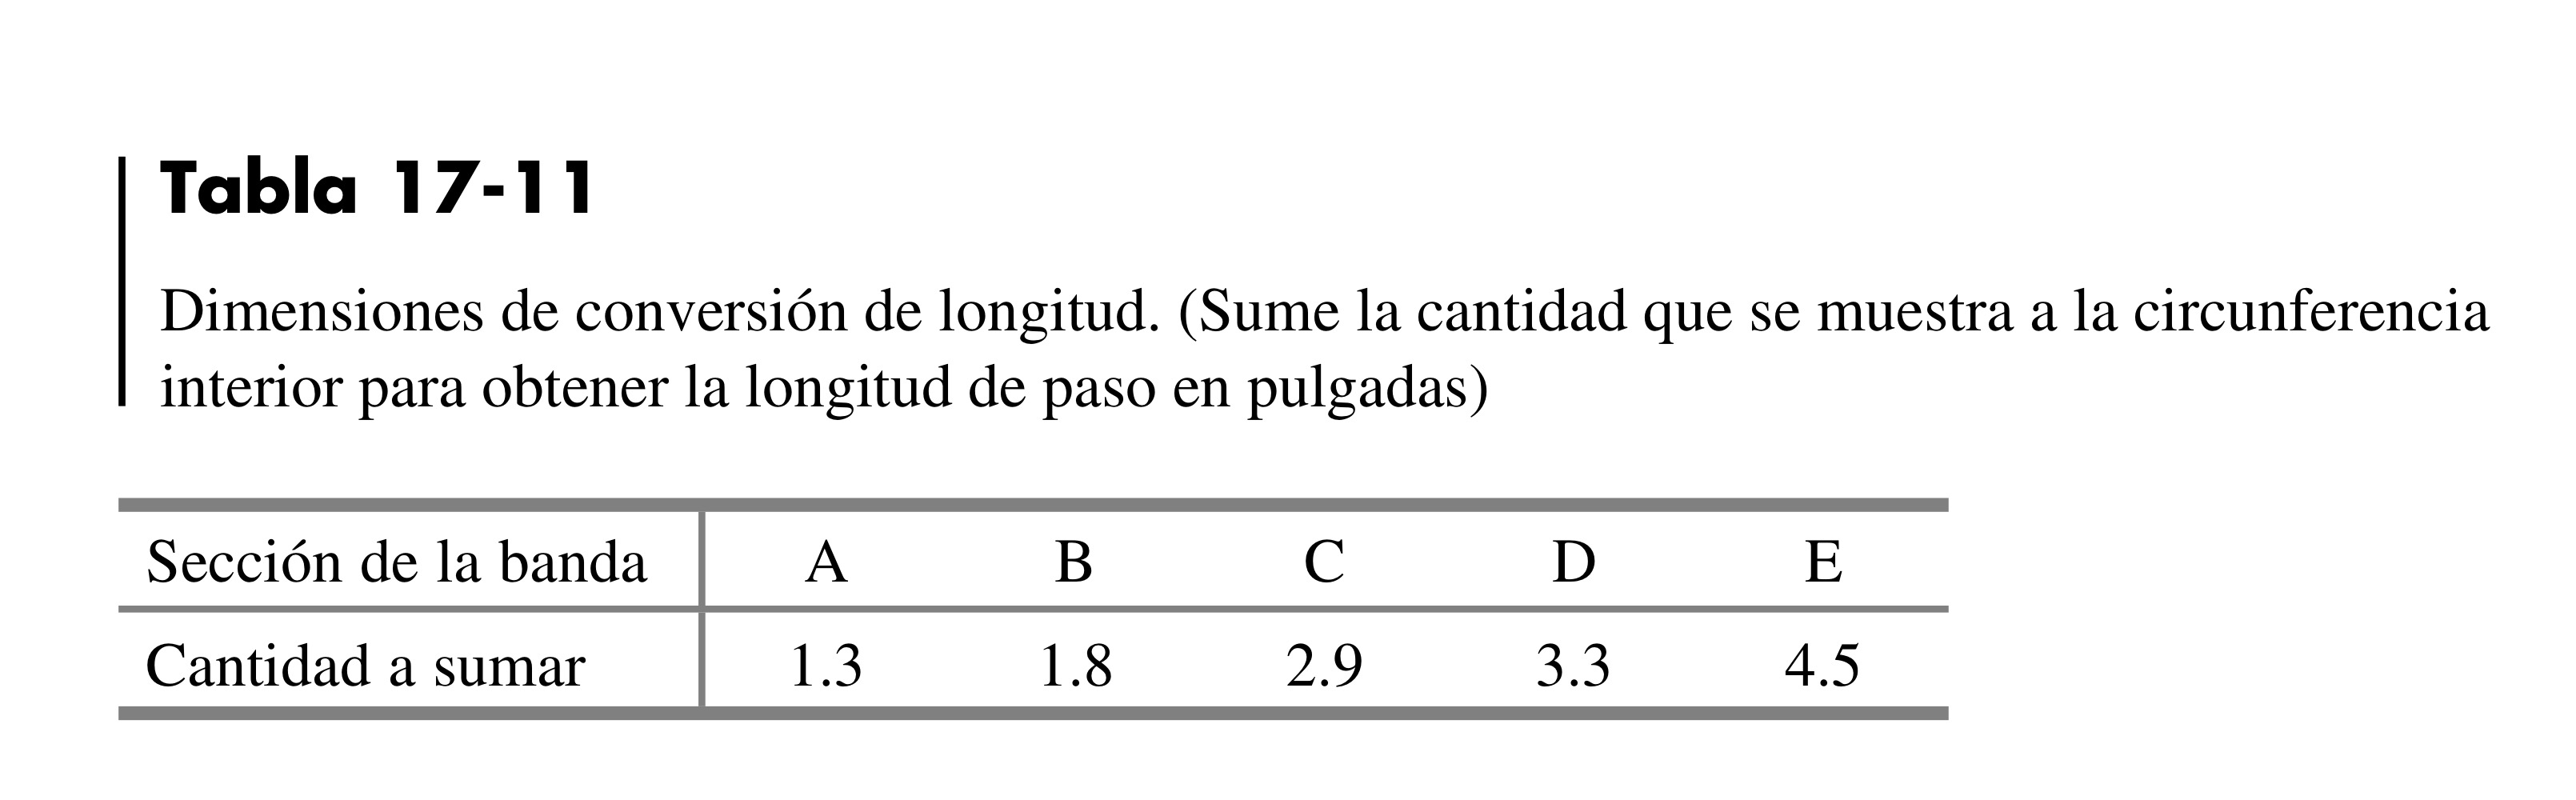

Si se desea calcular la longitud de paso requerida en función de los diámetros de las poleas y la distancia entre centros, se usa la siguiente relación:

$$
L_p = 2C + \frac{\pi (D + d)}{2} + \frac{(D - d)^2}{4C} 
$$

Si se conoce la longitud de paso y los diámetros de las poleas, y nnuestra incógnita es la distancia de centros a la cual se encuentran, esta está dada por:

$$
C = \frac{1}{4}([L_p - \frac{\pi (D + d)}{2}] + \sqrt{[L_p - \frac{\pi (D + d)}{2}] - 2(D - d)^2})
$$

Es recomendable que la distancia entre centros cumpla la siguiente relación:

$$
D < C < 3(D + d)
$$

In [106]:
def largo_paso_banda_V(C, D, d):
    '''Recibe:
    C: Distancia entre centros [m]
    D: Diámetro de la polea mayor [m]
    d: Diámetro de la polea menor [m]
    
    Retorna:
    L: Largo del paso de la banda plana [m]'''


    L = (np.pi * (D + d) / 2) + (2 * C) + ((D - d)**2 / (4 * C))

    return L

def distancia_centros_banda_V(L, D, d):
    '''Recibe:
    L: Largo del paso de la banda [m]
    D: Diámetro de la polea mayor [m]
    d: Diámetro de la polea menor [m]
    
    Retorna:
    C: Distancia entre centros [m]'''


    C = 0.25 * ( 
                (L - (np.pi * (D + d) / 2)) \
                + np.sqrt(((L - (np.pi * (D + d) / 2)) ** 2) - (2 * ((D - d) ** 2))) \
                ) 
            

    if D < C and C < 3 * (d + D):
        print("La distancia entre centros se encuentra en el rango adecuado.")
        print(f"Debe cumplirse: D < C < 3 * (d + D) --> {D} < {C:.2f} < {3 * (d + D)}")
    else:
        print("La distancia entre centros NO se encuentra en el rango adecuado ❌❌❌.")
        print(f"Debe cumplirse: D < C < 3 * (d + D) --> {D} < {C} < {3 * (d + D)}")

    return C

L_banda = 162 + 2.9 # in
d = 11 # in
D = 33 # in

C_ayudantia_6_1 = distancia_centros_banda_V(L_banda, D, d)

np.rad2deg(alpha_1_function(C_ayudantia_6_1, D, d))

print(velocity_function(1500, d))


La distancia entre centros se encuentra en el rango adecuado.
Debe cumplirse: D < C < 3 * (d + D) --> 33 < 46.59 < 132
4319.689898685966


### Ecuación de bandas en V

Ahora el contacto de la banda con la polea se hace con las zonas laterales de la banda, aumentando así su roce. Por tanto, se tiene un coeficiente de fricción efectivo $f'$ dado por:

$$
f' = \frac{f}{\sin \beta}
$$

Por lo tanto, la ecuación de las bandas es exactamente la misma que para las bandas planas pero ahora se usa el coeficiente de fricción efectivo.

$$
\frac{T_1 - T_c}{T_2 - T_c} = e^{f'\cdot \phi_D}
$$

Otra diferencia con respecto a las bandas planas es la forma de calcular el $T_c$, el cual se obtiene a partir de la siguiente ecuación:

$$
T_c = K_c (\frac{V}{1000})^2
$$
Donde $V$ es la velocidad de la banda en $[\frac{ft}{min}]$ y $K_c$ es una constante tabulada que depende del tipo de sección de la banda.

Debido al aumento de la sección transversal con respecto a las bandas planas, ahora se deberá considerar también la tensión por flexión de la banda, la cual está dada por:

$$
T_b = \frac{K_b}{D}
$$
Donde $K_b$ es una constante que depende de la sección de la banda

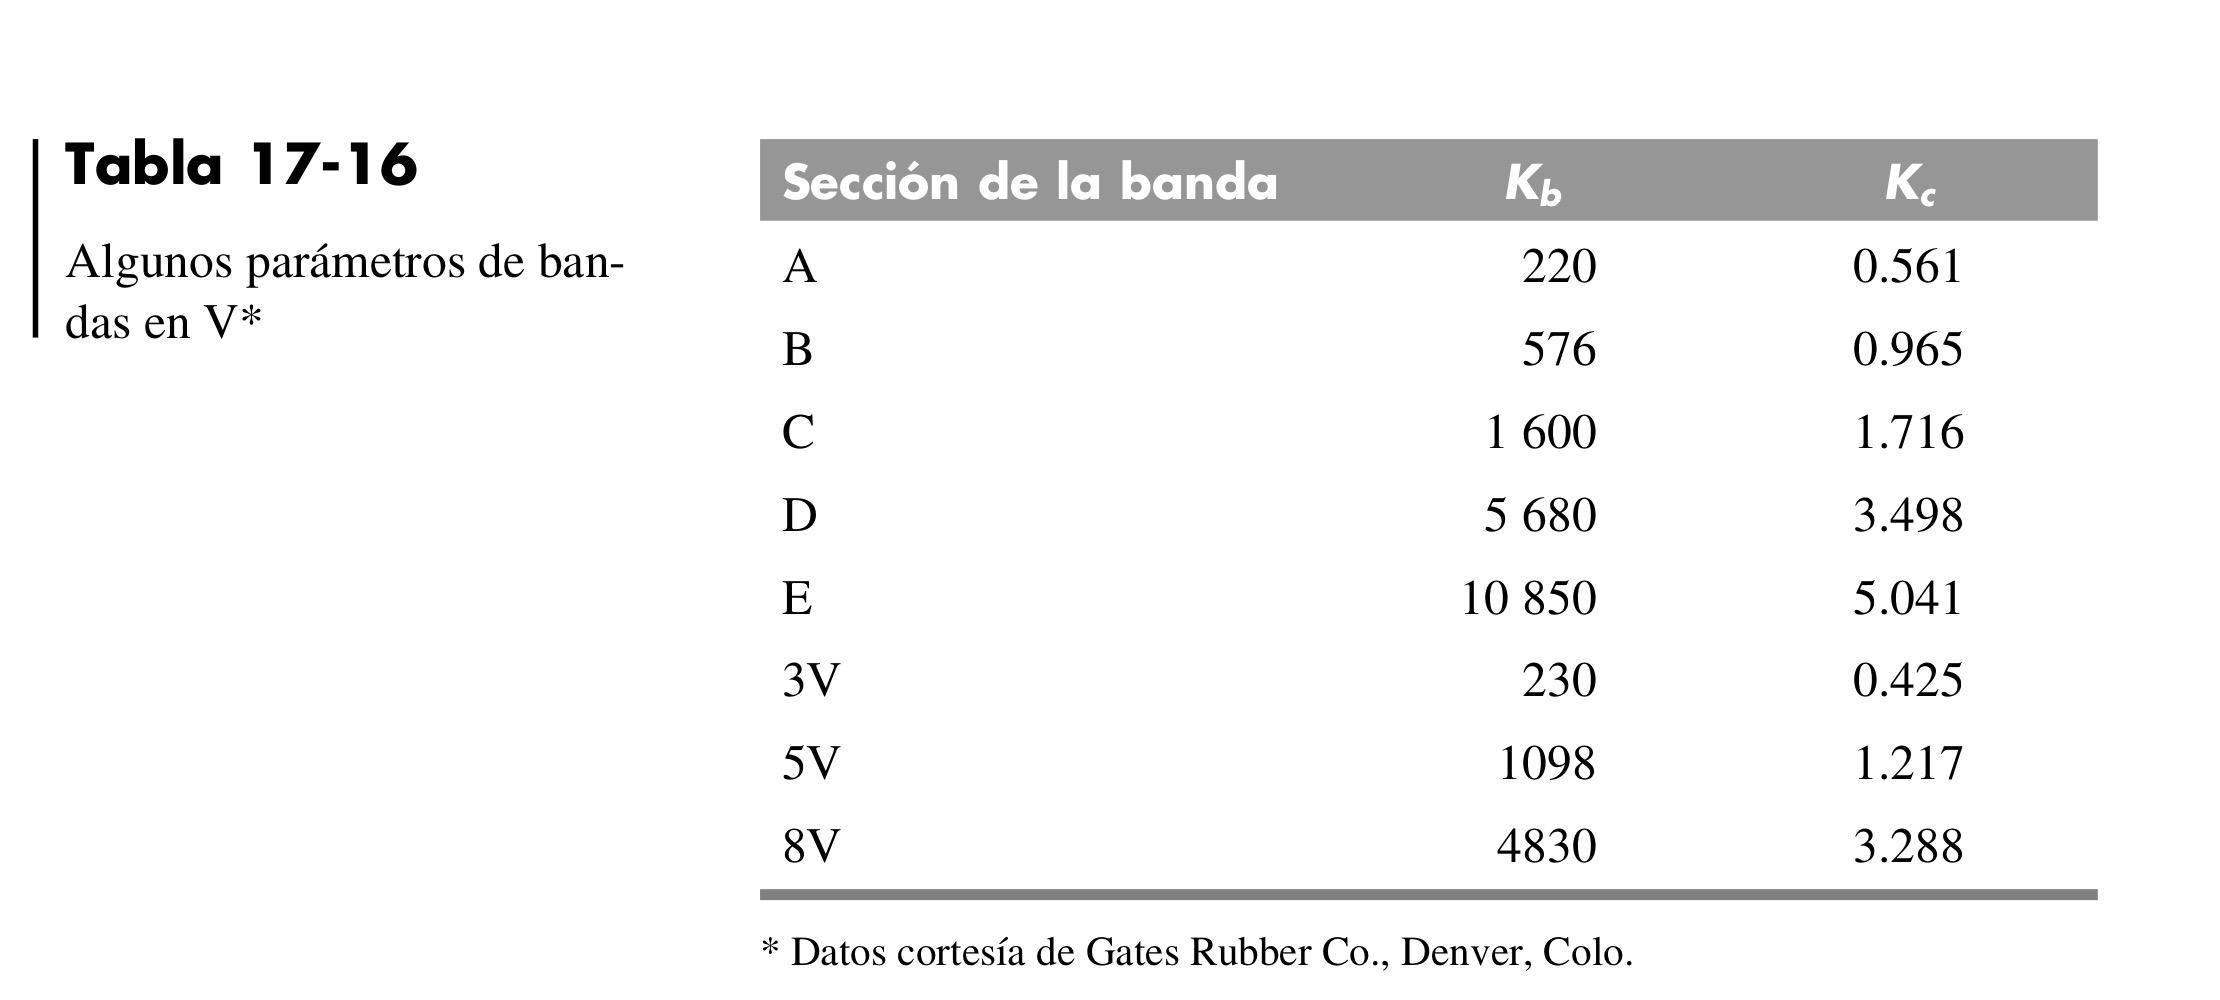

In [107]:
def T_c_banda_V(Kc, V):
    return Kc * (V / 1000)**2

def T_b_banda_V(Kb, D):
    return Kb / D

### Seguridad en bandas en V

El factor de seguridad en bandas planas se calcula con la siguiente fórmula:

$$
n_d = \frac{N_b(H)_{adm}}{H_d}
$$

Donde $N_b$ es el número de bandas utilizado, $H_{adm}$ es la potencia admisible por la banda y $H_d = H_{nom} \cdot K_s$ es la potencia transmitida con el factor de aplicación $K_s$. La potencia nominal está dada por:

$$
H_{nom} = (T_1 - T_2) \cdot V
$$
Donde $V$ es la velocidad lineal de la banda. $V = \frac{\omega D}{2}$.

Los fabricantes especifican la tensión máxima admisible $H_{adm}$, la cual debe ser corregida de la siguiente forma para obtener $(H)_{adm}$

$$
(H)_{adm} = H_{adm} K_1 K_2
$$

Donde:
- $K_1$: Factor de corrección por el ángulo de cobertura
- $K_2$: Factor de corrección por longitud de la banda

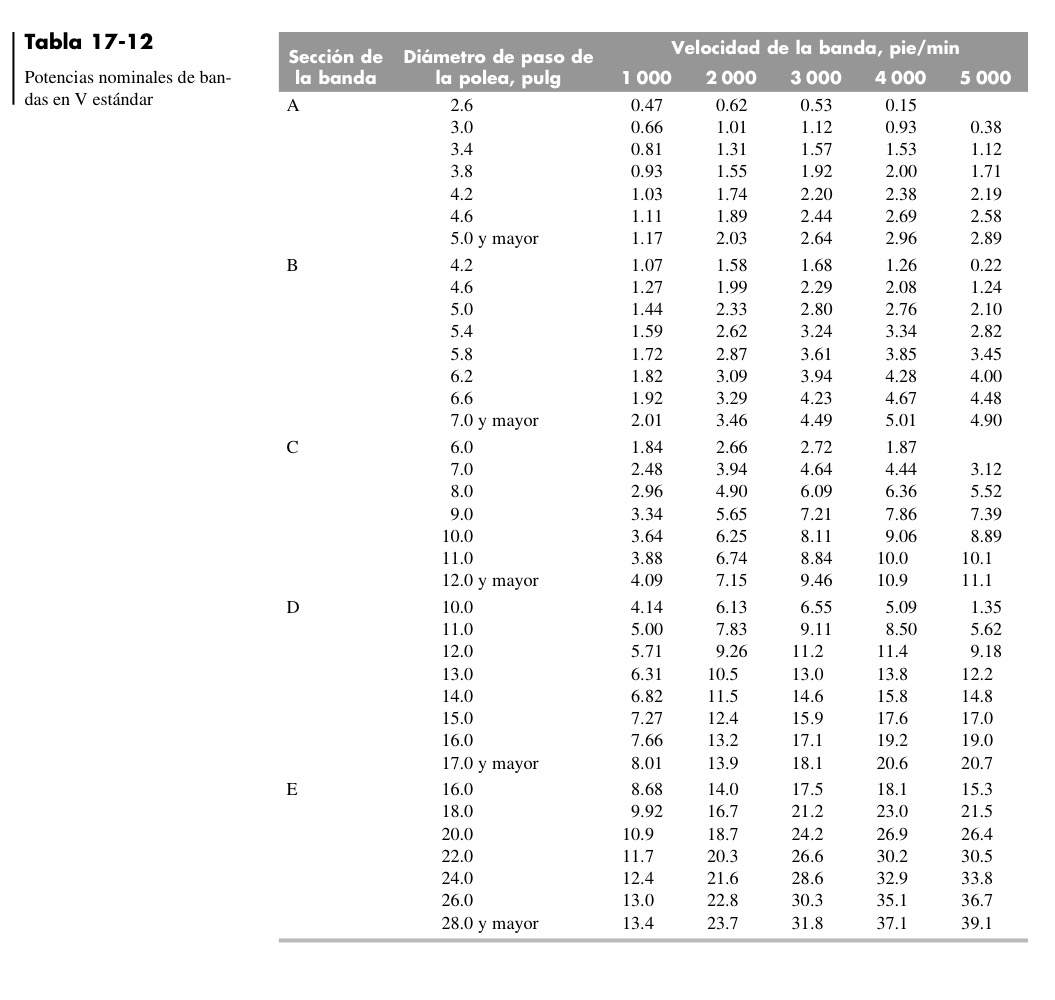
![JPEG image-4B3F-98BA-FD-0.jpeg](<attachment:JPEG image-4B3F-98BA-FD-0.jpeg>)
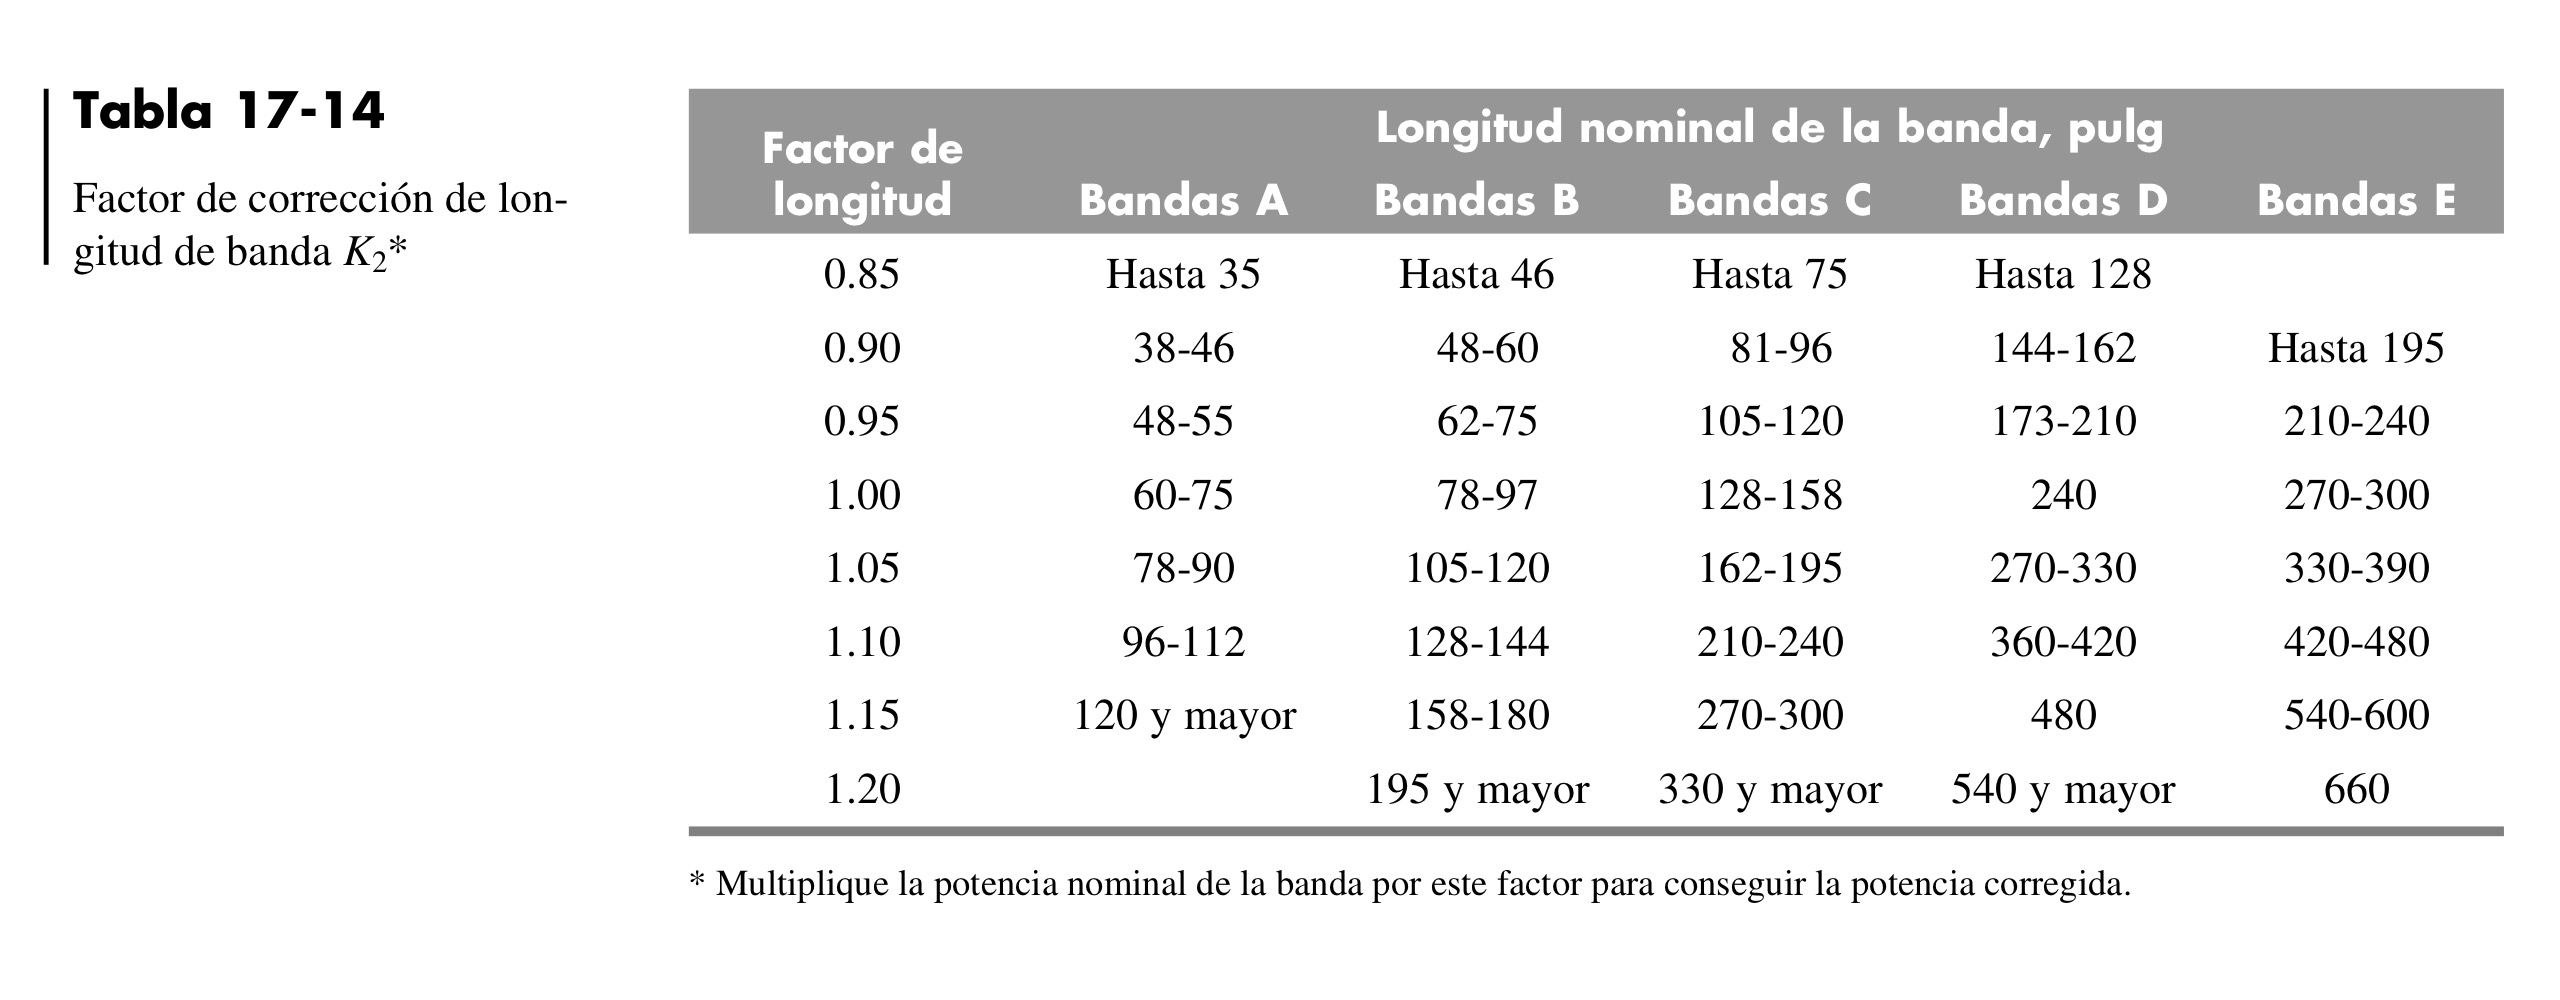
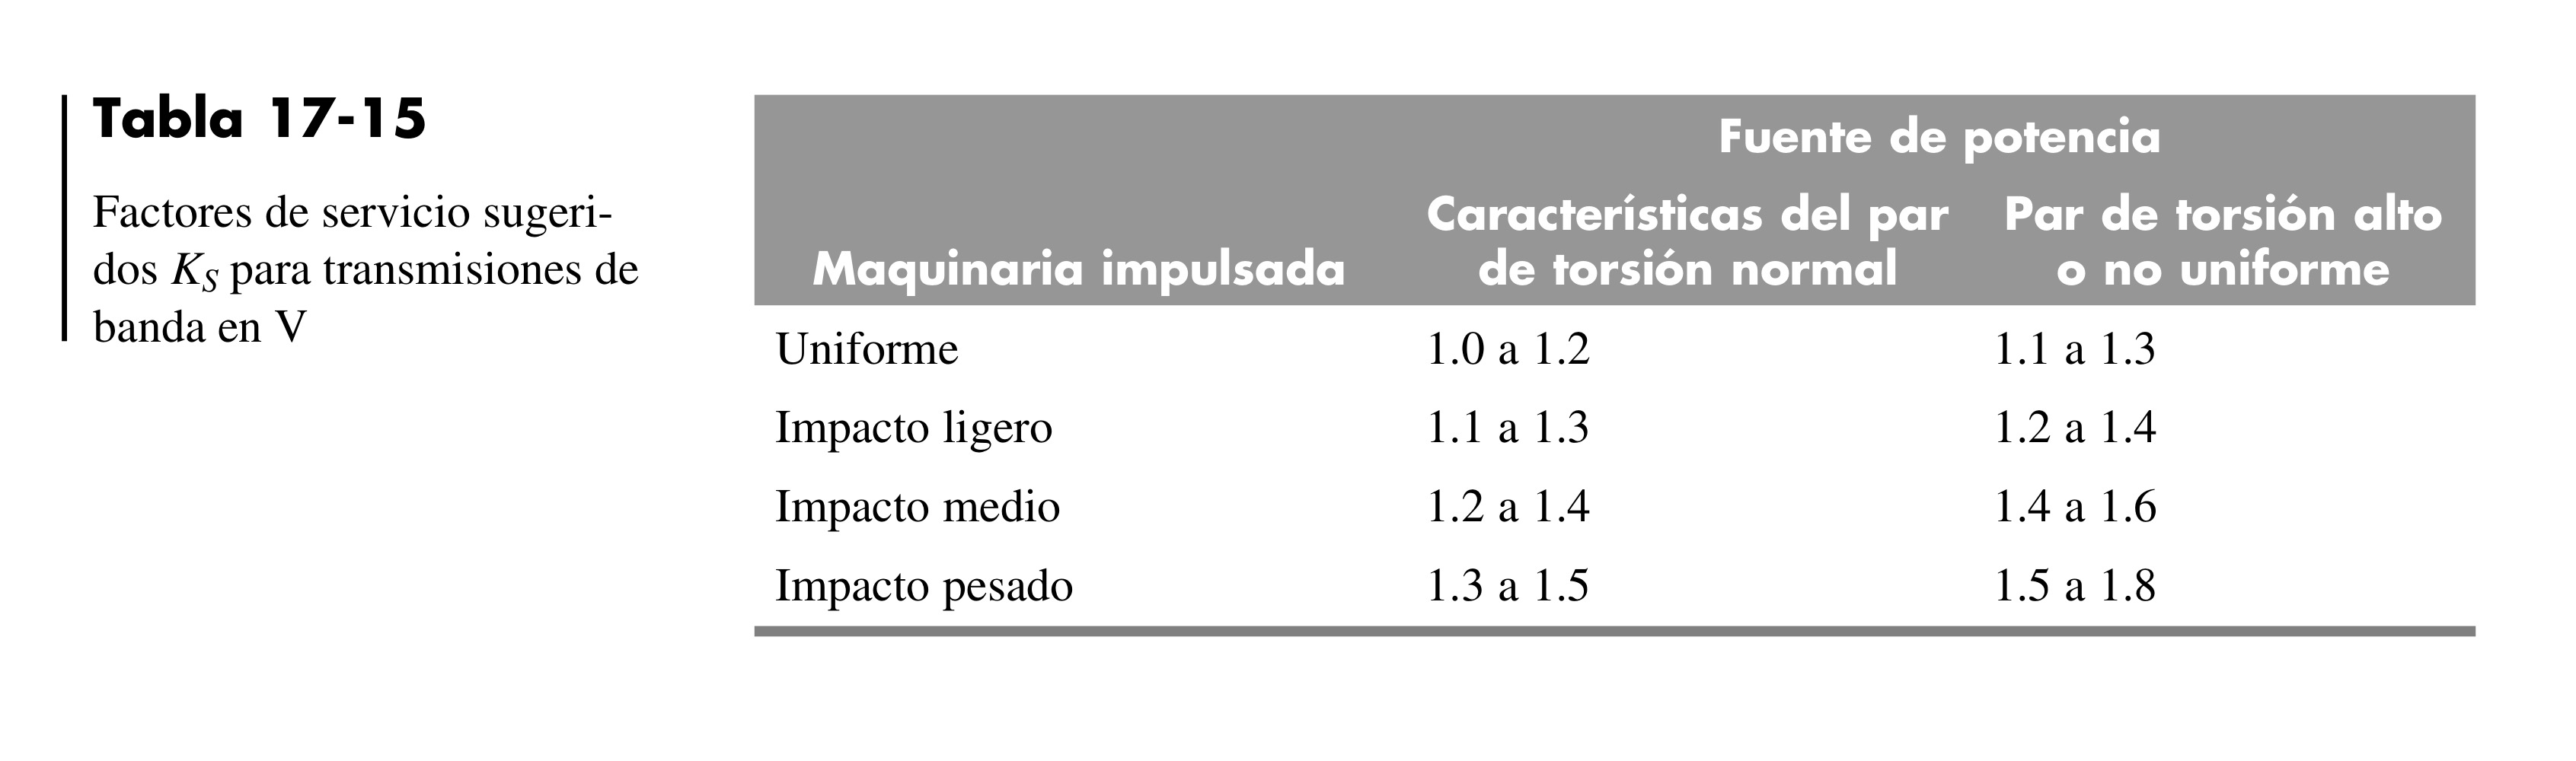


Ahora, además de la seguirdad por sobre-esfuerzo, se debe considerar la fatiga, para lo cual sirve como parámetro de utilizad el tiempo de vida de la banda. El número de ciclos para la falla debido a cada tensión $T_i$ está dado por:

$$
N_1 = (\frac{K}{P_1})^b \text{ con } P_1 = T_1 + T_b
$$

$$
N_2 = (\frac{K}{P_2})^b \text{ con } P_2 = T_2 + T_b
$$

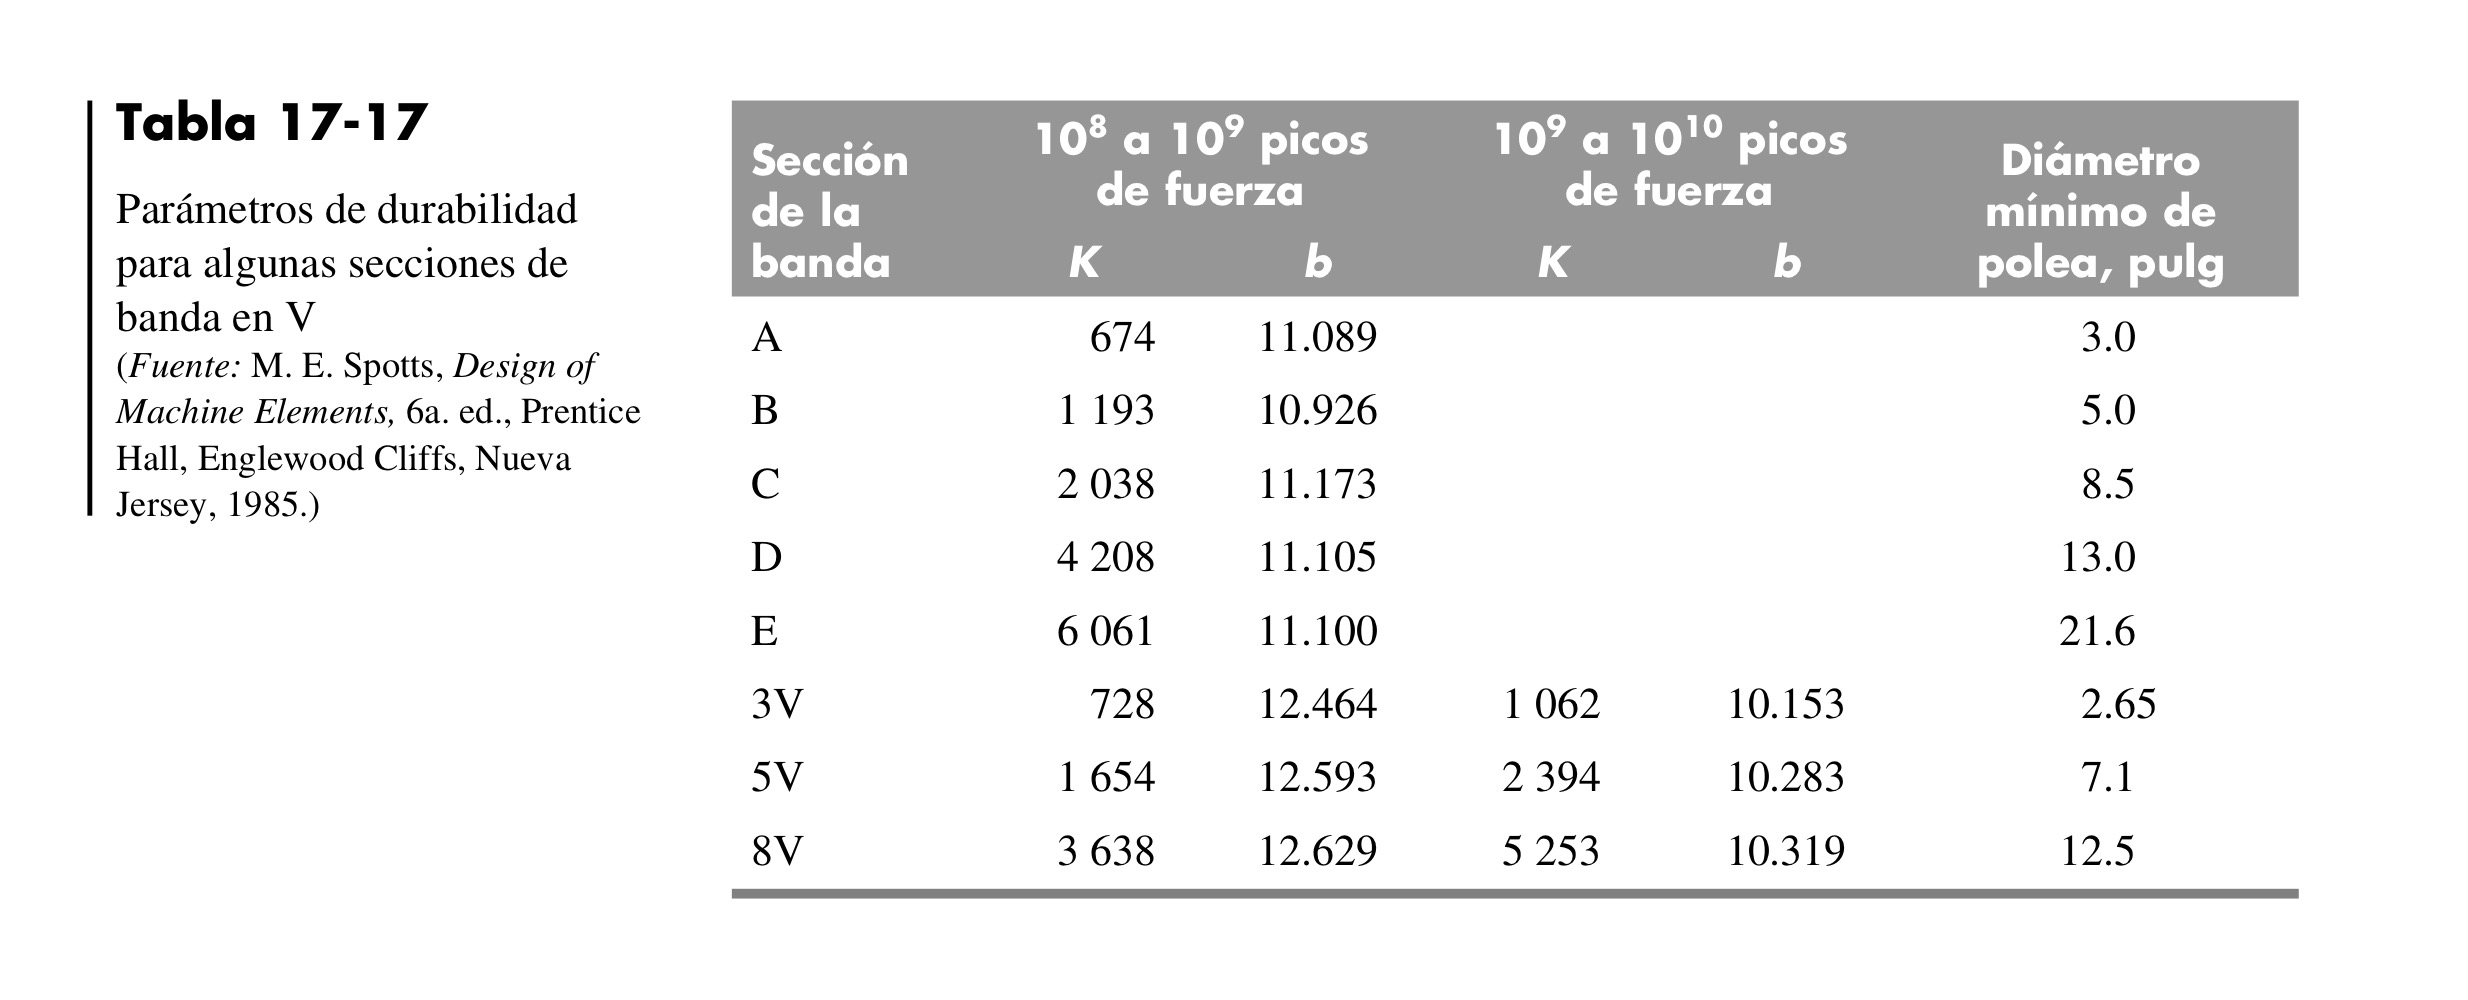

Con esto en mente, considerando que el número de veces que se aplica la tensión 1 es el mismo que el número de veces que se apalica la tensión 2, el número de ciclos hasta la fatiga está dado por:

$$
N_p = \frac{N_1 N_2}{N_1 + N_2}
$$

Así, el tiempo de vida de la banda será:

$$
t = \frac{L_p N_p}{V}
$$

El paso a paso para obtener el factor de seguridad de una banda plana es:

1. Calcular $\phi_D$ y $L_p$
2. Calcular $T_c$ y $T_b$
3. Calcular $(H)_{adm}$ usando $(H)_{adm} = H_{adm} K_1 K_2$
4. Calcular $M_{adm}$ usando $ M_{adm} = \frac{(H)_{adm}}{\omega}$ y $M_d$ usando $ M_{d} = \frac{H_{d}}{\omega}$
5. Calcular $(T_1)_{adm}$ usando $(T_1)_{adm} = T_c + \frac{M_{adm}}{D} \frac{2e^{f'\cdot \phi_D}}{e^{f'\cdot \phi_D} - 1}$
6. Calcular $T_2$ usando $T_2 = (T_1)_{adm} - 2\frac{M_{adm}}{2}$ 
7. Calcular el factor de seguridad $n_d = \frac{N_b H_{adm}}{H_d}$ y verificar que sea mayor a 1
8. Calcular $N_1$ y $N_2$ usando $N_1 = (\frac{K}{P_1})^b$ y $N_2 = (\frac{K}{P_2})^b$
9. Calcular $N_p = \frac{N_1 N_2}{N_1 + N_2}$
10. Calcular el tiempo de vida $t = \frac{L_p N_p}{V}$
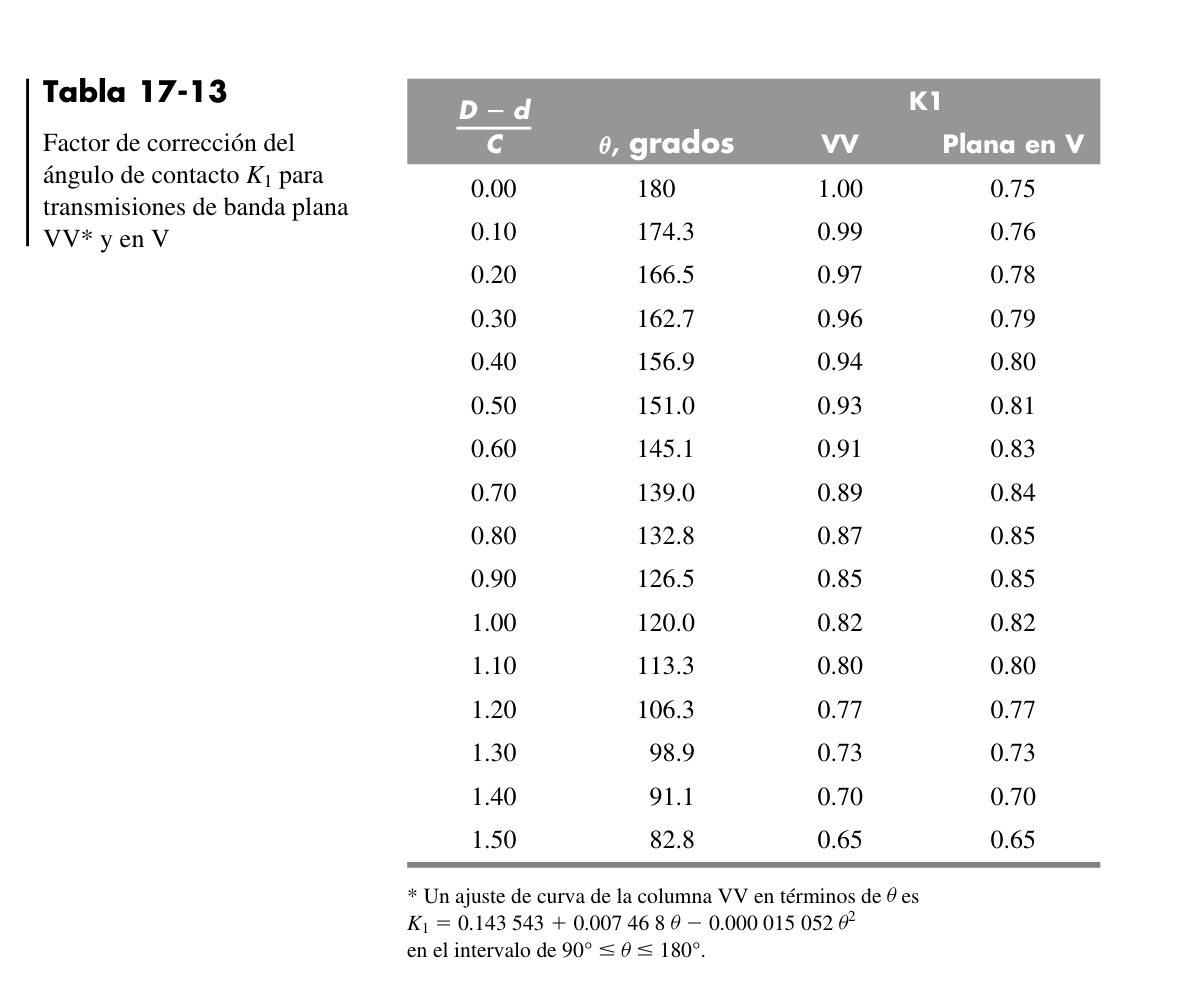

In [108]:
def seguridad_banda_V(H_nom, Ks, H_tabulada, K1, K2, Nb, omega_D, omega_d, C, D, d, Kc, Kb, f_prima, K, b, Lp):

    '''Código implementado para calcular el factor de seguridad y la vida útil de una banda en V
    
    Recibe:
    H_nom: Potencia nominal [hp]
    Ks: Factor de servicio
    H_tabulada: Potencia tabulada [hp]
    K1: Factor de corrección por ángulo de contacto
    K2: Factor de corrección por longitud de la banda
    Nb: Número de bandas
    omega_D: Velocidad de la polea mayor [rpm]
    omega_d: Velocidad de la polea menor [rpm]
    C: Distancia entre centros [ft]
    D: Diámetro de la polea mayor [ft]
    d: Diámetro de la polea menor [ft]
    Kc: Constante para cálculo de tensión centrífuga
    Kb: Constante para cálculo de tensión por flexión
    f_prima: Coeficiente de fricción efectivo
    K: Constante para cálculo de vida útil
    b: Exponente para cálculo de vida útil
    Lp: Largo del paso de la banda [ft]
    
    Retorna:
    Imprime una tabla con los resultados de los cálculos intermedios y finales.'''

    # Calcular la velocidad en ft/min
    V = omega_d * d * np.pi / 12 # ft/min

    # 1) Calcular phi_d y L_p
    phi_d = alpha_1_function(C, D, d)

    # 2) Calcular Tc
    Tc_calculado = T_c_banda_V(Kc, V)

    # 3) Calcular M_adm
    H_adm = H_tabulada * K1 * K2
    M_adm = 63025 * (H_adm / omega_d) # lbf * in 

    # 4) Calcular (T_1)_adm
    Fi = (M_adm / d) * ((np.exp(f_prima * phi_d) + 1) / (np.exp(f_prima * phi_d) - 1))

    T1_adm = Tc_calculado + (((M_adm / d)) * \
                             ((2 * np.exp(f_prima * phi_d)) / (np.exp(f_prima * phi_d) - 1)))

    # 5) Calcular T2
    T2 = T1_adm - (2 * M_adm / D)

    # 6) Calcular el factor de seguridad n_d
    H_d = H_nom * Ks
    n_d = H_adm * Nb / H_d

    # 7) Calcular N1 y N2
    P_1 = T1_adm + T_b_banda_V(Kb, d)
    N1 = (K / P_1) ** b

    P_2 = T1_adm + T_b_banda_V(Kb, D)
    N2 = (K / P_2) ** b

    # 8) Calcular el número de ciclos mínimo entre fallas
    Np = (N1 * N2) / (N1 + N2)

    # 9) Calcular la vida en horas
    t = Lp * Np / (V * 720) # horas

    # Print a table with the results
    table = [
        ["phi_d (grados)", f"{rad_to_deg(phi_d):.4f}"],
        ["Tc (lbf)", f"{Tc_calculado:.4f}"],
        ["M_adm (lbf * in)", f"{M_adm:.4f}"],
        ["T1_adm (lbf)", f"{T1_adm:.4f}"],
        ["T2 (lbf)", f"{T2:.4f}"],
        ["T_i (lbf)", f"{Fi}"],
        ["n_d", f"{n_d:.4f}"],
        ["P_1 (lbf)", f"{P_1:.4f}"],
        ["P_2 (lbf)", f"{P_2:.4f}"],
        ["N_p", f"{Np:.4f}"],
        ["V (ft/min)", f"{V:.4f}"],
        ["t (hrs)", f"{t:.4f}"]
    ]

    print(tabulate(table, headers=["Descripción", "Valor"], tablefmt="grid"))

H_nom = 10 # hp
Ks = 1.1
H_tabulada = 10.05 # hp
K1 = 0.81
K2 = 1.05
Nb = 1
omega_D = 500 # rpm
omega_d = 1500 # rpm
C = 46.59 # ft
D = 33 # ft
d = 11 # ft
Kc = 1.716
Kb = 1600
f_prima = 0.5123 # Uso el mencionado en el power
K = 2038
b = 11.173
Lp = 272.9 # ft

seguridad_banda_V(H_nom, Ks, H_tabulada, K1, K2, Nb, omega_D, omega_d, C, D, d, Kc, Kb, f_prima, K, b, Lp)


+------------------+------------------+
| Descripción      |            Valor |
+==================+==================+
| phi_d (grados)   |    152.687       |
+------------------+------------------+
| Tc (lbf)         |     32.0201      |
+------------------+------------------+
| M_adm (lbf * in) |    359.139       |
+------------------+------------------+
| T1_adm (lbf)     |    119.706       |
+------------------+------------------+
| T2 (lbf)         |     97.9405      |
+------------------+------------------+
| T_i (lbf)        |     55.0374      |
+------------------+------------------+
| n_d              |      0.777       |
+------------------+------------------+
| P_1 (lbf)        |    265.161       |
+------------------+------------------+
| P_2 (lbf)        |    168.191       |
+------------------+------------------+
| N_p              |      7.81969e+09 |
+------------------+------------------+
| V (ft/min)       |   4319.69        |
+------------------+------------------+


# Cadenas

### Geometría de cadenas

Las cadenas se encuentran más normadas que las correas. Cada cadena, dependiendo de su normativa, tiene su propio número, con el cual se puede conocer el paso, el ancho, peso promedio por unidad de largo, diámetro del rodillo, resistencia a la tensión, número de dientes disponibles, entre otros.

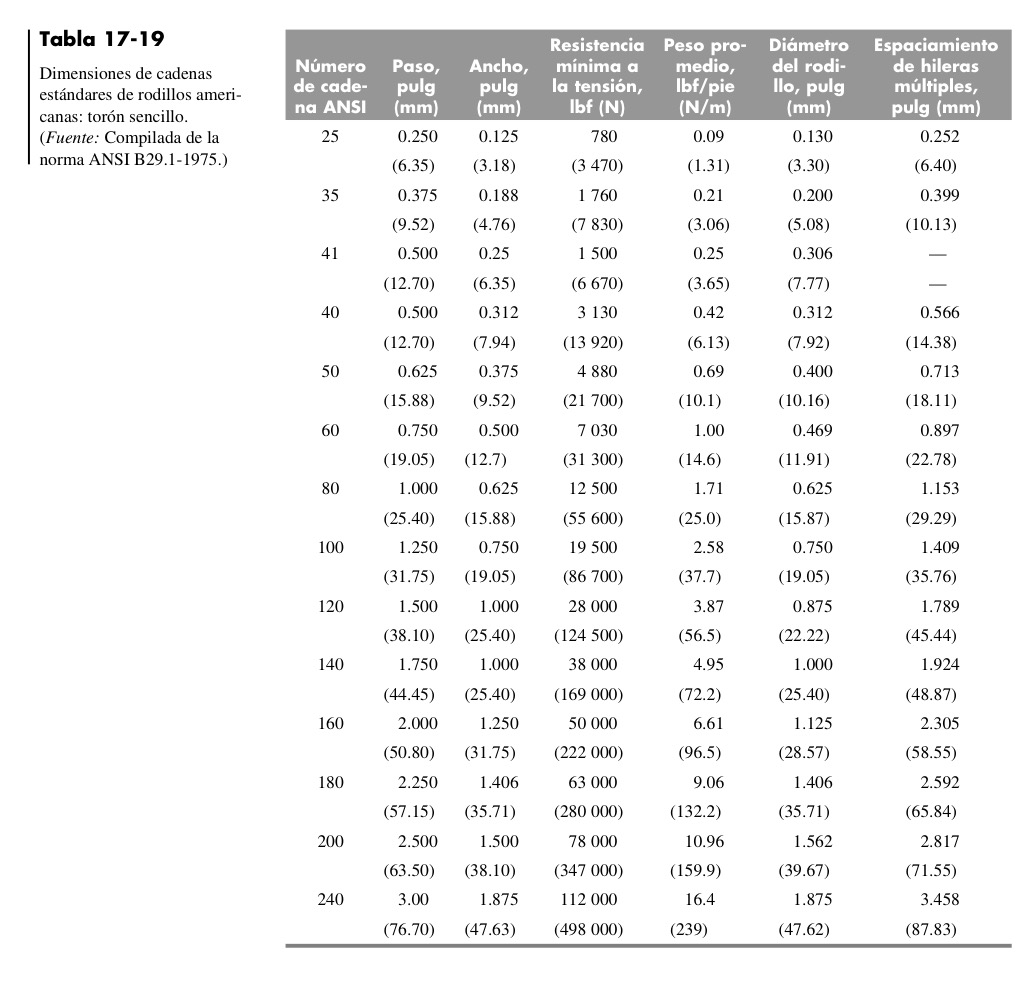 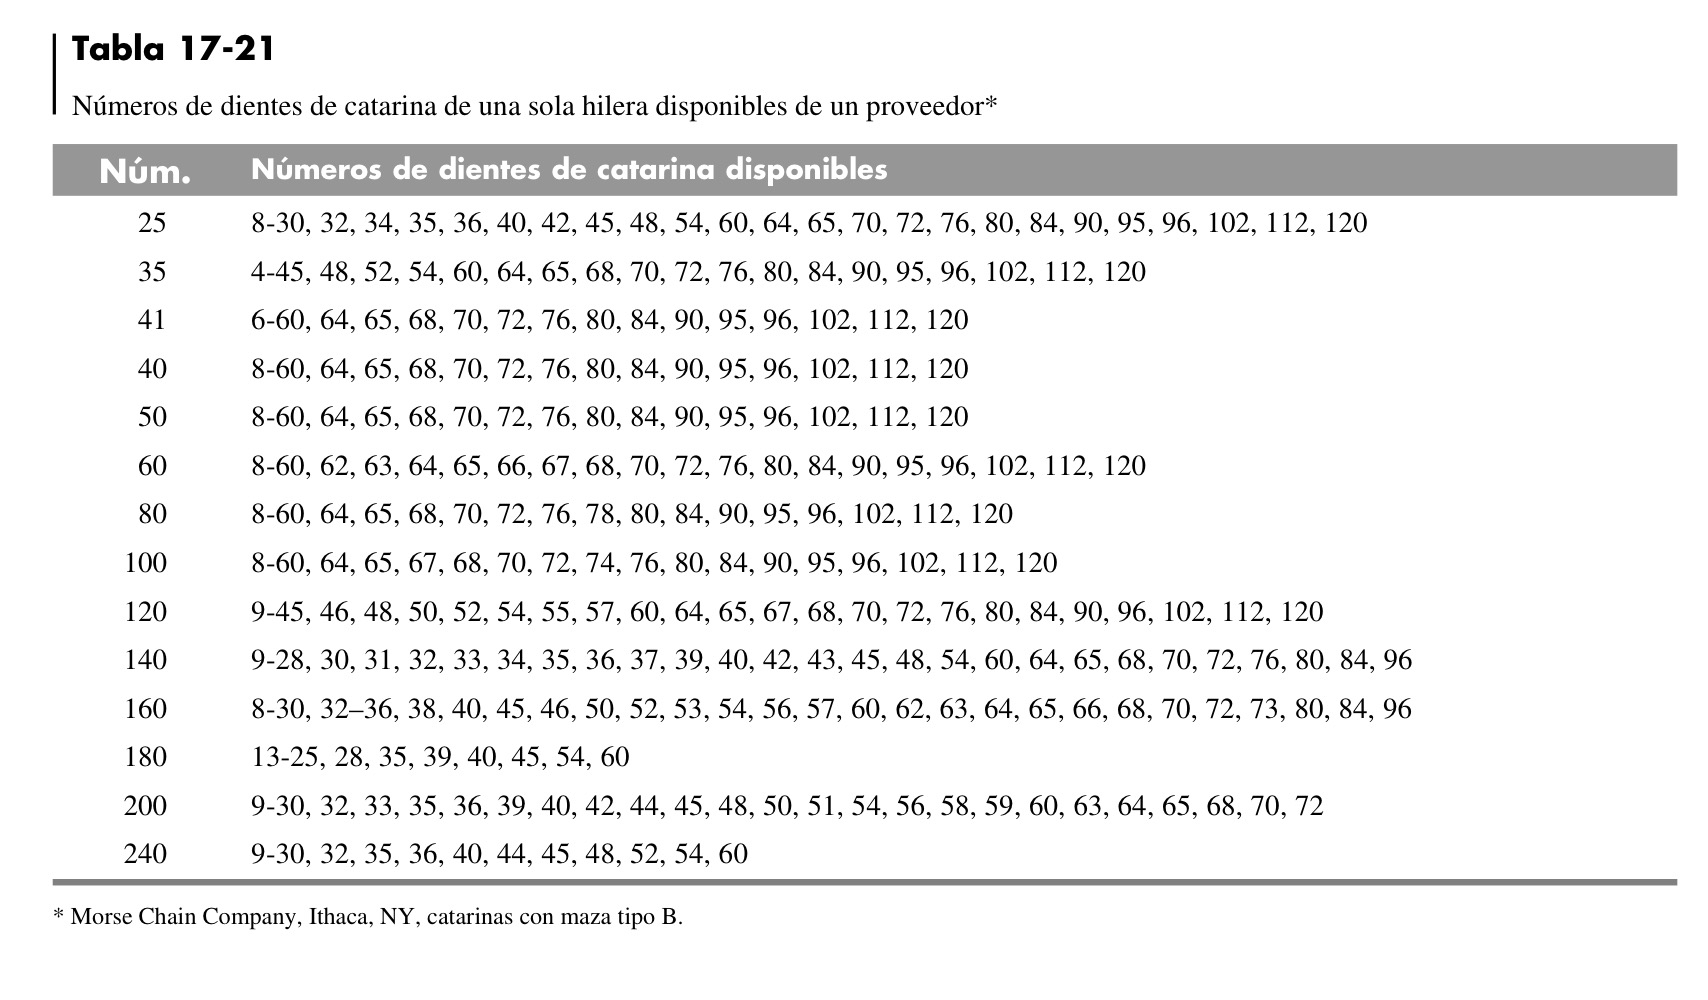

La longitud de la cadena por unidad de paso en función de la distancia entre centros está dada por:
$$
\frac{L}{p} = \frac{2C}{p} + \frac{N_1 + N_2}{2} + \frac{(N_2 - N_1)^2}{\frac{4\pi^2 C}{p}}
$$

De forma similar, la distancia entre centros en función del largo por unidad de paso está dada por:

$$
C = \frac{p}{4} [-A + \sqrt{A^2 - 8(\frac{N_2 - N_1}{2\pi})^2}]
$$

Donde:

$$
A = \frac{N_1 + N_2}{2} - \frac{L}{p}
$$


Los diámetros de los piñones (o catarinas) en función del paso y del número de dientes es:

$$
D = \frac{p}{\sin \frac{180}{N}}
$$


In [109]:
def largo_unidad_paso(N1, N2, C_p):
    '''
    Calcula el largo de la cadena por unidad de paso.

    Recibe:
    N1 (int): Número de dientes piñón 1
    N2 (int): Número de dientes piñón 2
    C (float): Distancia entre centros
    p (float): Paso de la cadena
    '''

    return ((2 * C_p)) + ((N1 + N2) / 2) + (((N2 - N1) ** 2) / (4 * (np.pi ** 2) * C_p))

def distancia_entre_centros(N1, N2, p, L_p):
    '''
    Calcula la distancia entre centros.

    Recibe:
    N1 (int): Número de dientes piñón 1
    N2 (int): Número de dientes piñón 2
    p (float): Paso de la cadena
    L (int): Largo de la cadena
    '''

    A = ((N1 + N2) / 2) - (L_p)
    C = (p / 4) * (-A + np.sqrt( (A**2) - 8 * ((N2 - N1) / (2 * np.pi)) ** 2))
    return C

def diametro_pinon(N, p):
    '''
    Calcula el diámetro primitivo del piñón.

    Recibe:
    N (int): Número de dientes del piñón
    p (float): Paso de la cadena
    '''

    return p / (np.sin( np.deg2rad(180 / N)))

### Seguirdad en cadenas

El procedimiento de cálculo de seguridad es muy parecido al de las cadenas en V, simplemente cambia la forma de calcular los coeficientes.

El factor de seguridad en bandas planas se calcula con la siguiente fórmula:

$$
n_d = \frac{(H)_{adm}}{H_d} = \frac{1}{N_t}
$$

Donde $N_t$ es el número de torones utilizado, $H_{adm}$ es la potencia admisible por la banda y $H_d = H_{nom} \cdot K_s$ es la potencia transmitida con el factor de aplicación $K_s$. La potencia nominal está dada por:

$$
H_{nom} = (T_1 - T_2) \cdot V
$$
Donde $V$ es la velocidad lineal de la banda. $V = \frac{\omega D}{2}$.

Los fabricantes especifican la tensión máxima admisible $H_{adm}$, la cual debe ser corregida de la siguiente forma para obtener $(H)_{adm}$

$$
(H)_{adm} = H_{adm} K_1 K_2
$$

Donde:
- $K_1$: Factor de corrección por número de dientes
- $K_2$: Factor de corrección por torones múltiples

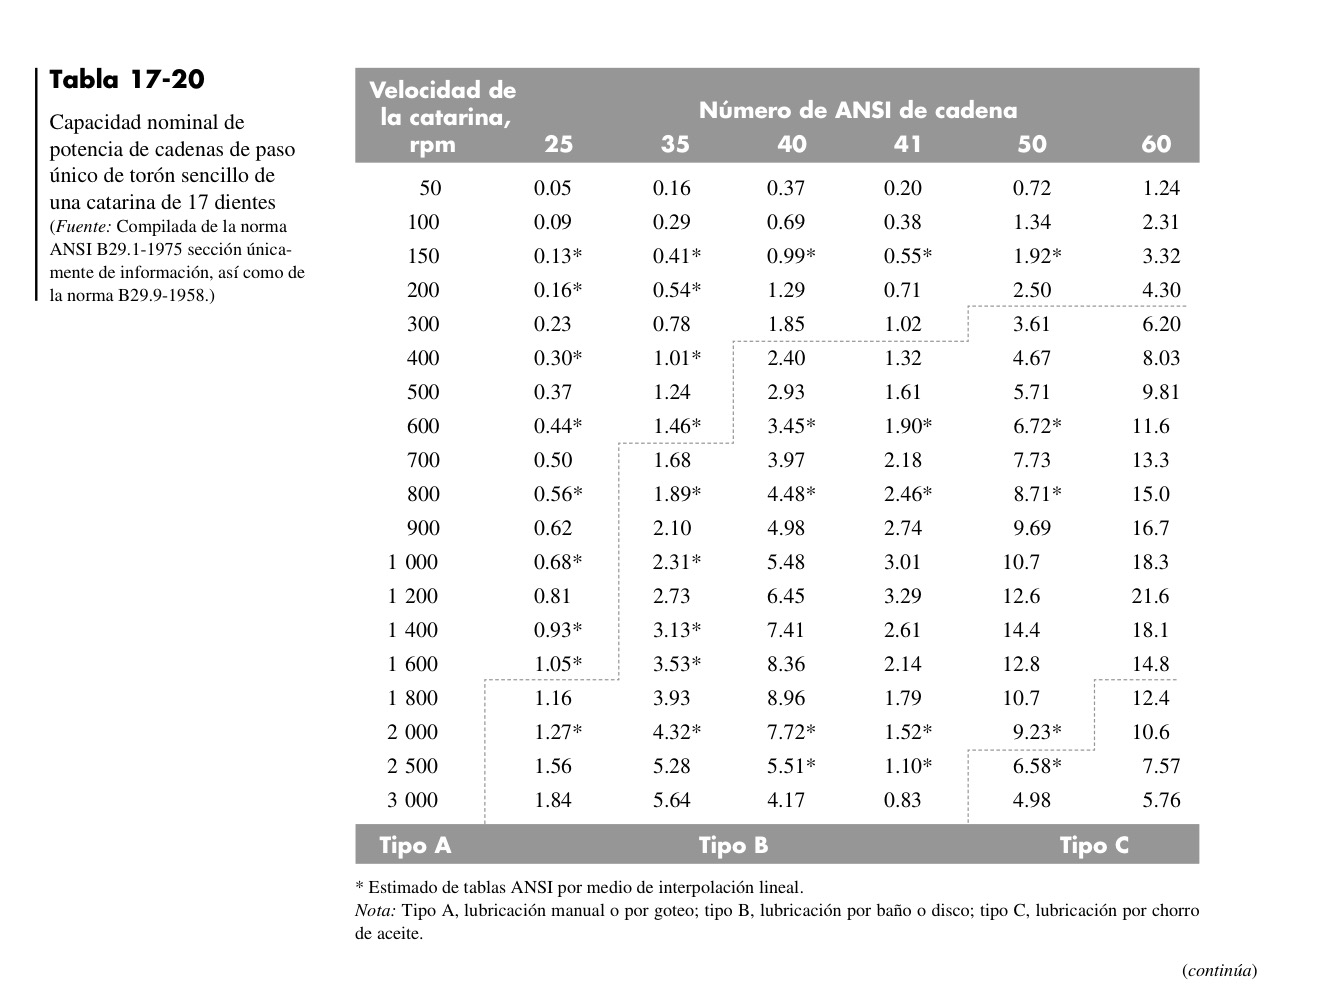 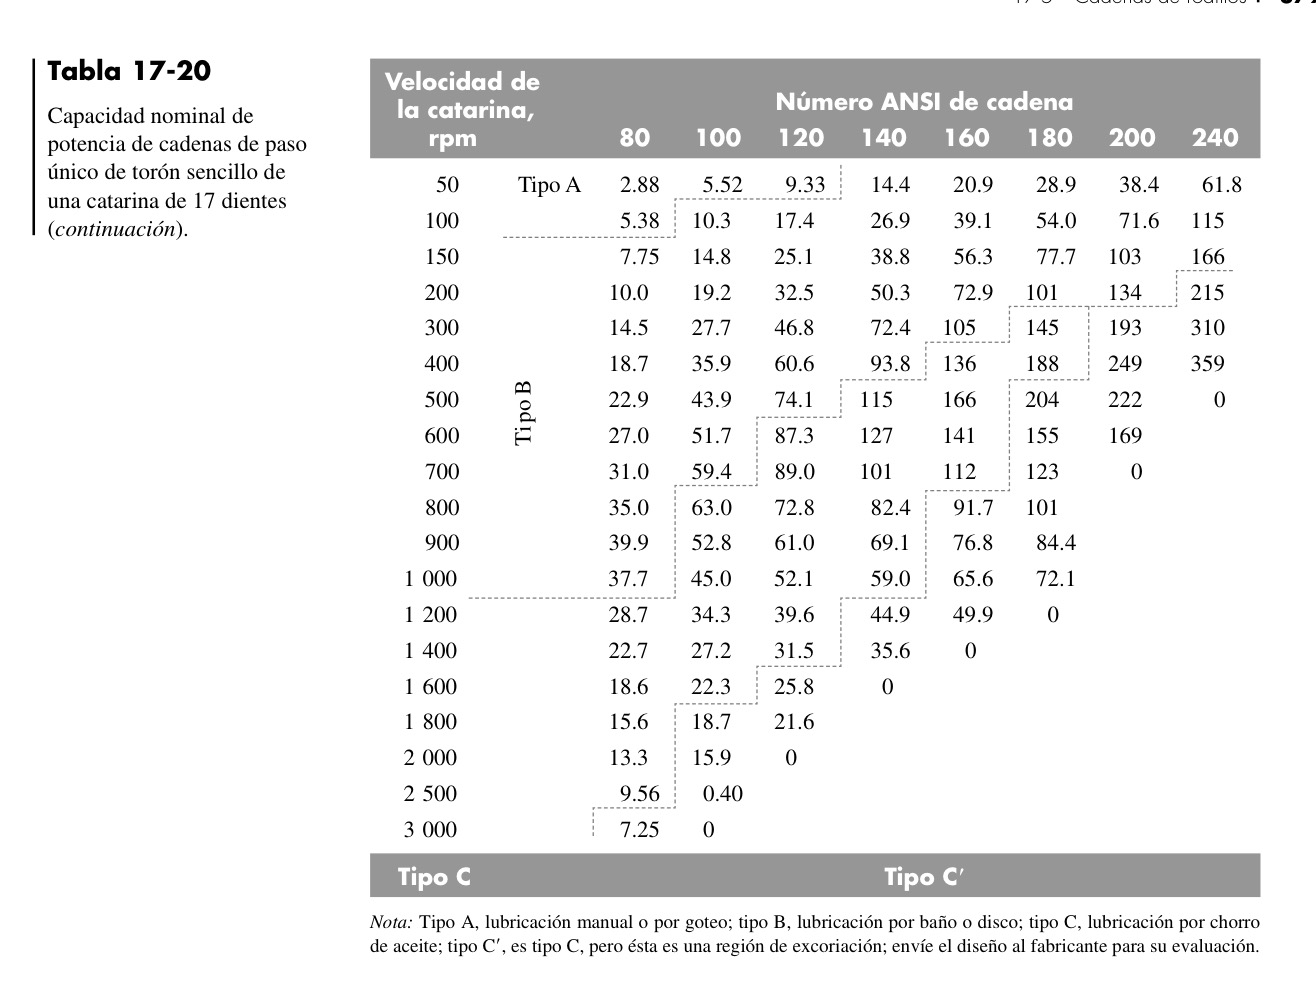 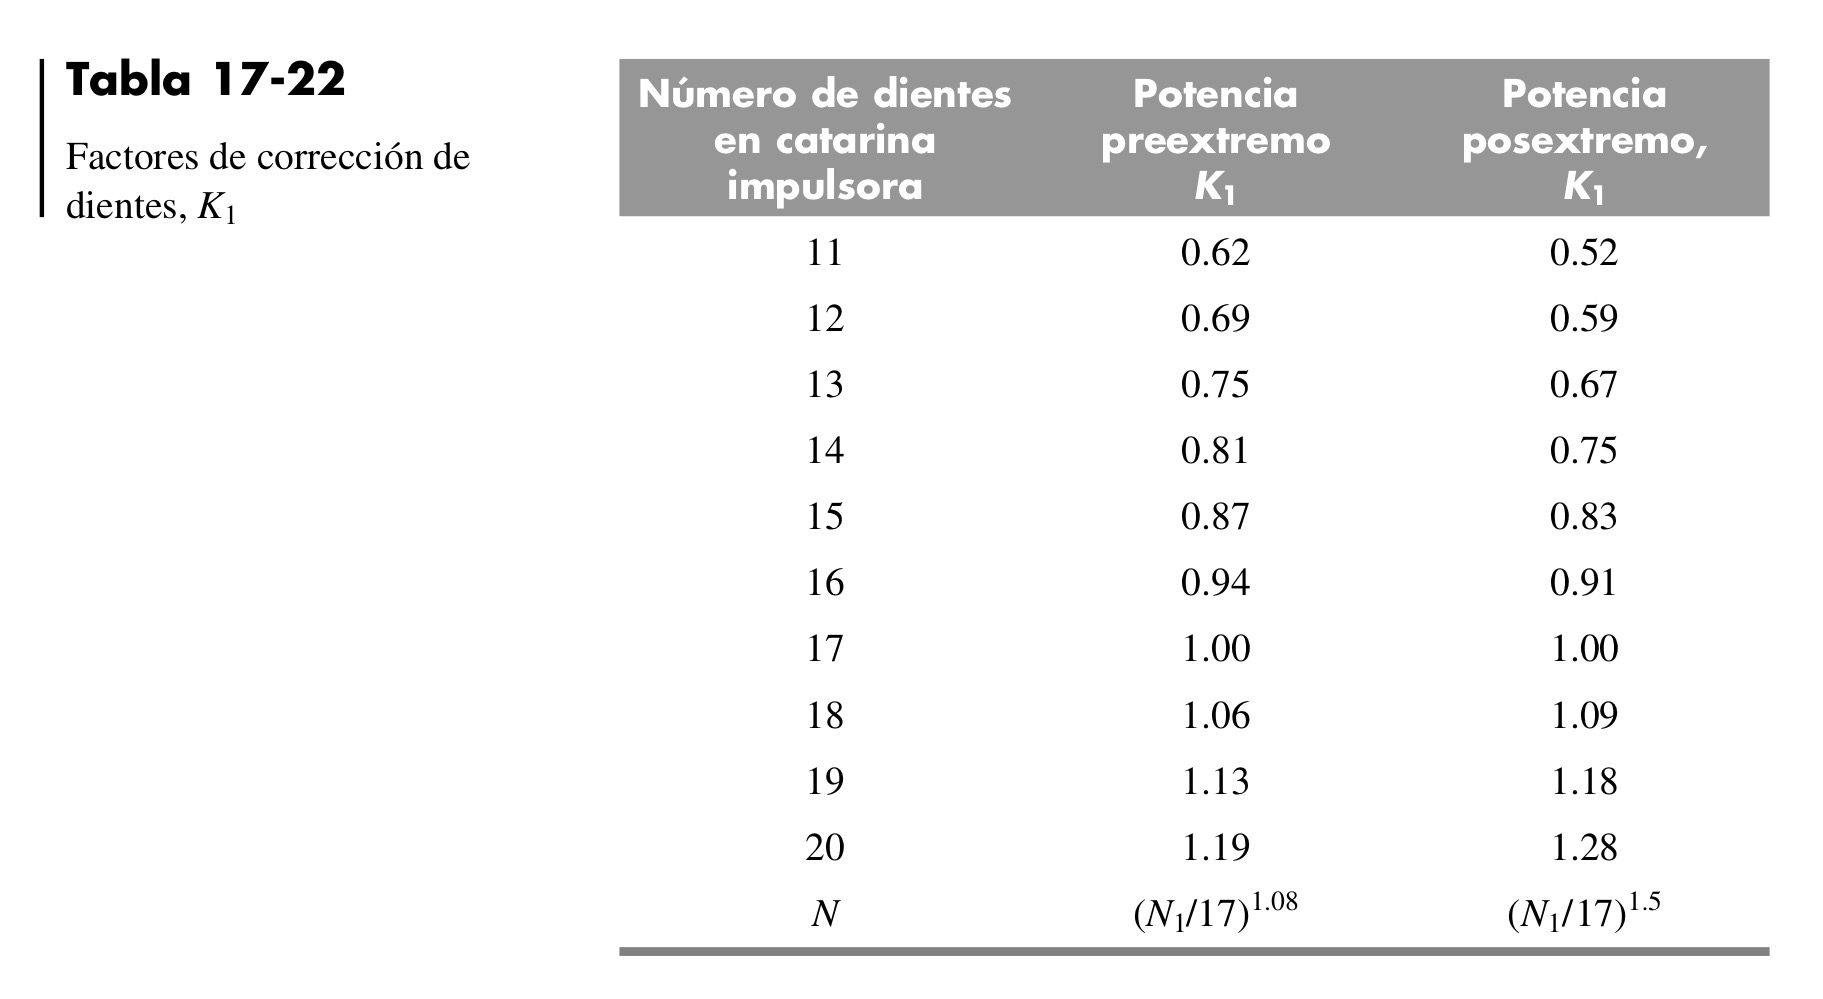 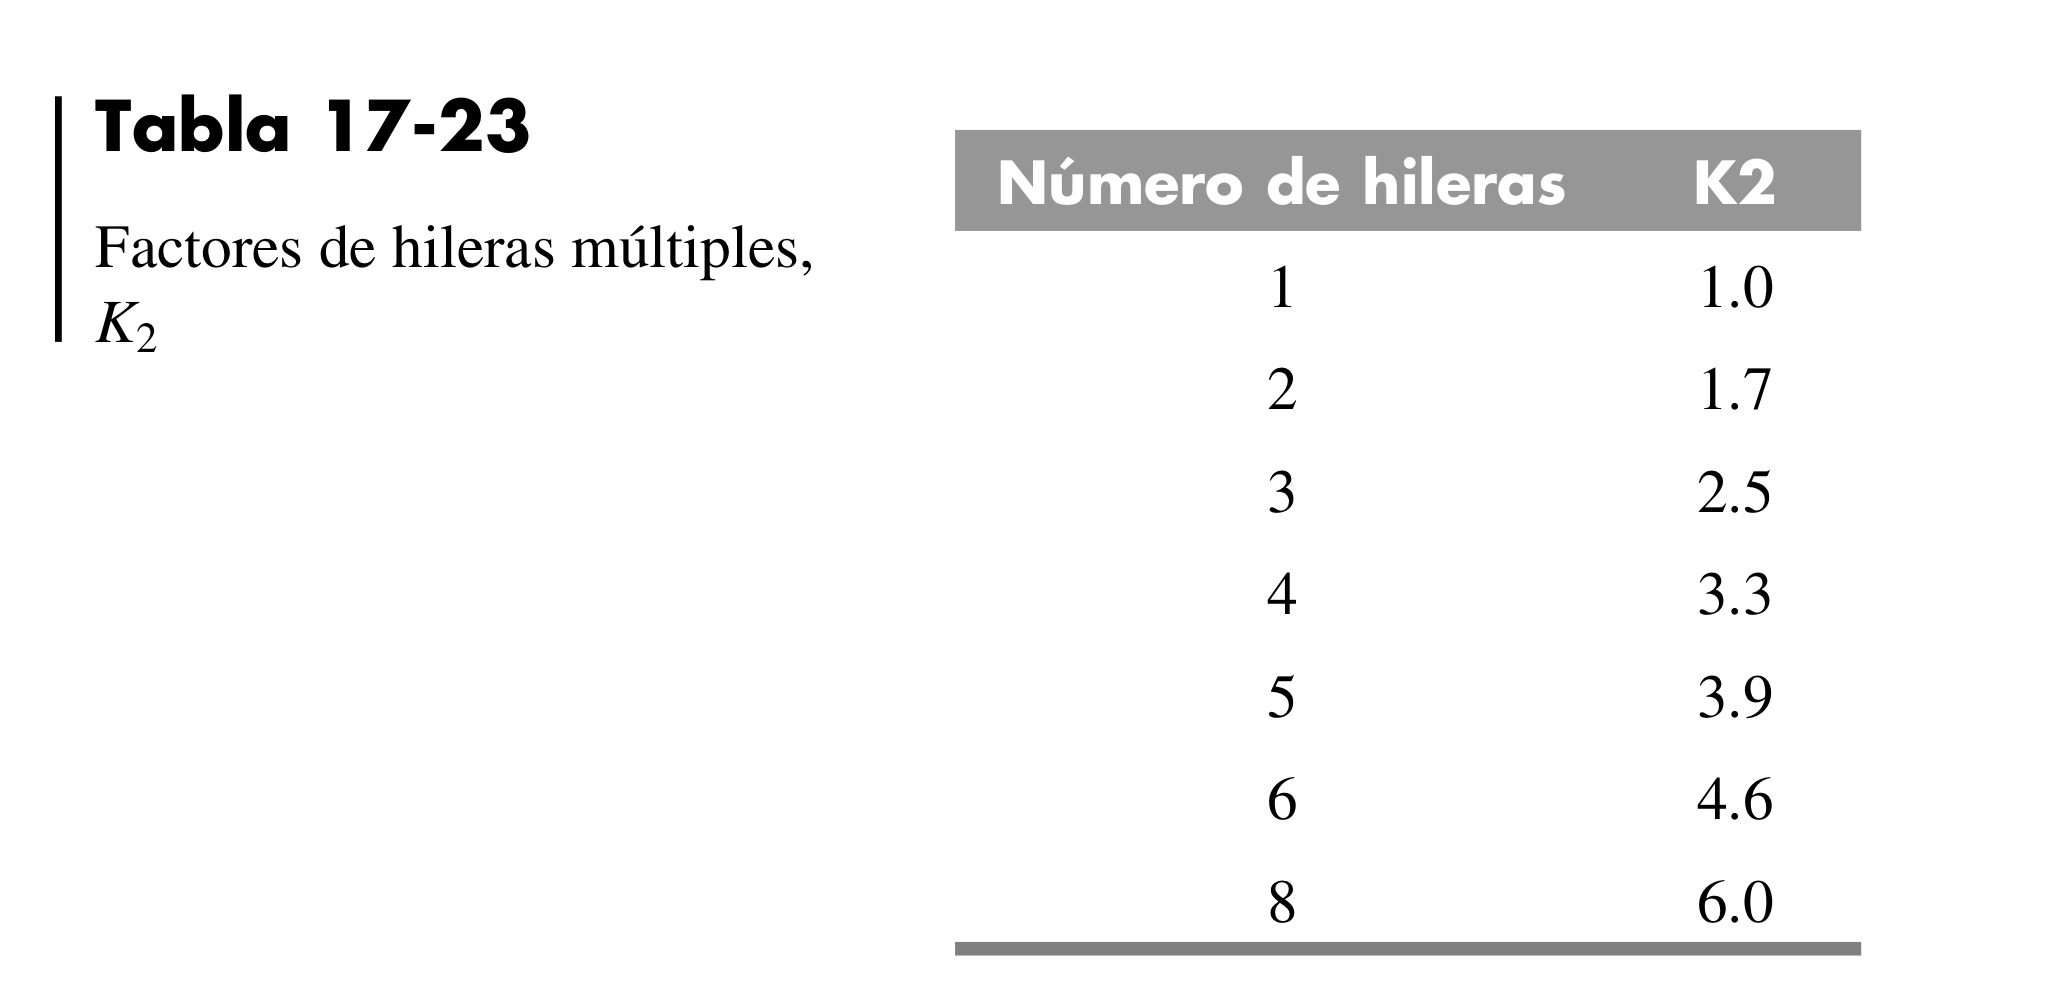

In [110]:
def potencias_tabuladas_requeridas(H_nom, Ks, n_d, K1):
    '''
    Calcula las potencias tabuladas requeridas en función del número de torones usados.

    Recibe:
    H_nom (float): Potencia nominal
    Ks (float): Factor de servicio
    n_d (float): Factor de seguridad requerido
    K1 (float): Factor de corrección por número de dientes en catarina
    '''

    K2_list = [1, 1.7, 2.5, 3.3, 3.9, 4.6, 6.0]
    Nt_list = [1, 2, 3, 4, 5, 6, 8]

    for i in range(len(K2_list)):
        K2 = K2_list[i]
        Nt = Nt_list[i]

        H_tabulada = (H_nom * Ks * n_d) / (K1 * K2)

        print(f"Para K2 = {K2} y Nt = {Nt}, la potencia tabulada mínima requerida es: H_tabulada >= {H_tabulada:.2f} hp")

H_nom = 90
Ks = 1.3
n_d = 1.5
K1 = 1

potencias_tabuladas_requeridas(H_nom, Ks, n_d, K1)


Para K2 = 1 y Nt = 1, la potencia tabulada mínima requerida es: H_tabulada >= 175.50 hp
Para K2 = 1.7 y Nt = 2, la potencia tabulada mínima requerida es: H_tabulada >= 103.24 hp
Para K2 = 2.5 y Nt = 3, la potencia tabulada mínima requerida es: H_tabulada >= 70.20 hp
Para K2 = 3.3 y Nt = 4, la potencia tabulada mínima requerida es: H_tabulada >= 53.18 hp
Para K2 = 3.9 y Nt = 5, la potencia tabulada mínima requerida es: H_tabulada >= 45.00 hp
Para K2 = 4.6 y Nt = 6, la potencia tabulada mínima requerida es: H_tabulada >= 38.15 hp
Para K2 = 6.0 y Nt = 8, la potencia tabulada mínima requerida es: H_tabulada >= 29.25 hp


In [111]:
def seguridad_en_cadenas(N1, N2, C_p, p, H_nom, Ks, H_tabulada, K1, K2):
    '''
    Calcula la seguridad en cadenas.

    Recibe:

    N1 (int): Número de dientes piñón 1
    N2 (int): Número de dientes piñón 2
    C_p (float): Razón C/p
    p (float): Paso de la cadena
    H_nom (float): Potencia nominal [hp]
    Ks (float): Factor de servicio
    H_tabulada (float): Potencia tabulada [hp]
    K1 (float): Factor de corrección por número de dientes en catarina
    K2 (float): Factor de corrección por número de torones

    '''

    # Calcular el largo por unidad de paso
    Lp = np.round(largo_unidad_paso(N1, N2, C_p))

    # Calcular la distancia entre centros
    C_calculado = distancia_entre_centros(N1, N2, p, Lp)

    # Calcular el diámetro primitivo de los piñones
    D1 = diametro_pinon(N1, p)
    D2 = diametro_pinon(N2, p)

    # Calcular la potencia de diseño
    H_d = H_nom * Ks

    # Calcular la potencia admisible
    H_adm = H_tabulada * K1 * K2

    # Calcular el factor de seguridad
    n_d = H_adm / H_d

    # print a table with the results
    table = [
        ["Largo por unidad de paso (mm)", f"{Lp:.2f}"],
        ["Distancia entre centros (mm)", f"{C_calculado:.2f}"],
        ["Diámetro primitivo piñón 1 (mm)", f"{D1:.2f}"],
        ["Diámetro primitivo piñón 2 (mm)", f"{D2:.2f}"],
        ["Potencia de diseño (W)", f"{H_d:.2f}"],
        ["Potencia admisible corregida (W)", f"{H_adm:.2f}"],
        ["Factor de seguridad (n_d)", f"{n_d:.2f}"]
    ]

    print(tabulate(table, headers=["Descripción", "Valor"], tablefmt="grid"))

N1 = 17
N2 = 34
C_p = 25
p = 44.45 # mm
H_nom = 90 # hp
H_tabulada = 72.4 # hp
Ks = 1.3
K1 = 1
K2 = 2.5 # Nt = 3

seguridad_en_cadenas(N1, N2, C_p, p, H_nom, Ks, H_tabulada, K1, K2)

+----------------------------------+---------+
| Descripción                      |   Valor |
+==================================+=========+
| Largo por unidad de paso (mm)    |   76    |
+----------------------------------+---------+
| Distancia entre centros (mm)     | 1115.88 |
+----------------------------------+---------+
| Diámetro primitivo piñón 1 (mm)  |  241.91 |
+----------------------------------+---------+
| Diámetro primitivo piñón 2 (mm)  |  481.75 |
+----------------------------------+---------+
| Potencia de diseño (W)           |  117    |
+----------------------------------+---------+
| Potencia admisible corregida (W) |  181    |
+----------------------------------+---------+
| Factor de seguridad (n_d)        |    1.55 |
+----------------------------------+---------+


Factor de seguridad a 1000 rpm

In [112]:
# Calcular la potencia admisible por la cadena

K1 = (28 / 17) ** (1.5) # Factor de corrección de dientes (Usamos N1 = 28 para el piñón impulsor)
K2 = 1.7 # Factor de corrección de hileras múltiples (Usamos 3 hileras)
Nt = 2 # Número de torones utilizados
H_tabulado = 52.1 # Potencia tabulada para la cadena seleccionda (Cadena 120 ANSI Tipo C)
H_adm = (K1 * K2) * H_tabulado 

# Calcular la potencia transmitida por la cadena

H_nom = 80 # Potencia nominal de la máquina [hp]
Ks = 1.8 # Factor de aplicación
Hd = H_nom * Ks # Potencia de diseño

# Calcular el factor de seguridad

n_d = (Nt* H_adm) / Hd

# Imprimir los resultados
tabla = [
    ["Potencia admisible por torón (H_adm)", H_adm],
    ["Número de torones", Nt],
    ["Potencia de diseño (H_d)", Hd],
    ["Factor de seguridad (n_d)", n_d]
]   

print(tabulate(tabla, headers=["Parámetro", "Valor"], tablefmt="grid"))



+--------------------------------------+-----------+
| Parámetro                            |     Valor |
+======================================+===========+
| Potencia admisible por torón (H_adm) | 187.219   |
+--------------------------------------+-----------+
| Número de torones                    |   2       |
+--------------------------------------+-----------+
| Potencia de diseño (H_d)             | 144       |
+--------------------------------------+-----------+
| Factor de seguridad (n_d)            |   2.60027 |
+--------------------------------------+-----------+


Factor de seguridad a 1250 rpm

In [113]:
# Calcular la potencia admisible por la cadena

H_tabulado = 37.575 # Potencia tabulada para la cadena seleccionda (Cadena 120 ANSI Tipo C)
H_adm = (K1 * K2) * H_tabulado 

n_d = (Nt* H_adm) / Hd

# Imprimir los resultados
tabla = [
    ["Potencia admisible por torón (H_adm)", H_adm],
    ["Número de torones", Nt],
    ["Potencia de diseño (H_d)", Hd],
    ["Factor de seguridad (n_d)", n_d]
]   

print(tabulate(tabla, headers=["Parámetro", "Valor"], tablefmt="grid"))



+--------------------------------------+-----------+
| Parámetro                            |     Valor |
+======================================+===========+
| Potencia admisible por torón (H_adm) | 135.024   |
+--------------------------------------+-----------+
| Número de torones                    |   2       |
+--------------------------------------+-----------+
| Potencia de diseño (H_d)             | 144       |
+--------------------------------------+-----------+
| Factor de seguridad (n_d)            |   1.87534 |
+--------------------------------------+-----------+


Ahora voy a asumir que $\frac{C}{p} = 40$. Como la cadena es ANSI 120, esta posee un paso de $p = 38.1\; [mm]$

In [114]:
# Interpolación para calcular la potencia a 1250 rpm
39.6 + (((31.5 - 39.6) / (200)) * 50)

37.575